---
<h1 style="text-align: center;"><strong>Data Science & Statistical Computing</strong></h1>
<h2 style="text-align: center;"><strong>CheckPoint05</strong></h2>
<h3 style="text-align: center;"><strong>Random Forest, XGBoost e LightGBM: modelagem, tuning, avaliação e deploy</strong></h3>
<h4 style="text-align: center;"><strong>Versão única</strong></h4>

<style>
.jp-MarkdownOutput, .text_cell_render {
    font-family: "Latin Modern Roman", "CMU Serif", Georgia, "DejaVu Serif", serif;
    font-size: 18px;
    line-height: 1.6;
}
.jp-MarkdownOutput p, .text_cell_render p,
.jp-MarkdownOutput li, .text_cell_render li {
    line-height: 1.6;
}
</style>

<div style="border-left: 4px solid #666; padding: 10px 16px; margin: 18px 0;">
<strong>Configuração visual:</strong> o notebook prioriza tipografia serifada para células Markdown. A renderização de CSS pode variar entre Jupyter Notebook, JupyterLab, VS Code e Google Colab; quando uma fonte não estiver disponível, o visualizador utilizará uma alternativa local. O código permanece com fonte monoespaçada do ambiente.
</div>

<br>

---

<br>

## **Identificação dos alunos**

A atividade deve ser realizada em **grupos de no máximo 5 alunos**. Preencha, abaixo, o nome e o RM de cada integrante do grupo. Caso o grupo tenha menos de cinco integrantes, mantenha sem preenchimento os campos não utilizados.


In [1]:
#@title Identificação
Nome_1 = "Thiago Nascimento" #@param {type:"string"}
RM_1 = "561967" #@param {type:"string"}
Nome_2 = "Vinicius Herreira" #@param {type:"string"}
RM_2 = "565662" #@param {type:"string"}
Nome_3 = "Gustavo Rocha" #@param {type:"string"}
RM_3 = "564152" #@param {type:"string"}
Nome_4 = "Gabriel Santos" #@param {type:"string"}
RM_4 = "562419" #@param {type:"string"}
Nome_5 = "" #@param {type:"string"}
RM_5 = "" #@param {type:"string"}

<br>

---

<br>

# **CheckPoint05**

## **Objetivos**

- Estruturar um problema real de **classificação** ou **regressão** a partir de uma base de dados escolhida pelo grupo.
- Realizar **data wrangling**, análise exploratória e seleção justificada das variáveis preditoras.
- Implementar e comparar **Random Forest**, **XGBoost** e **LightGBM** sob o mesmo protocolo experimental.
- Ajustar hiperparâmetros com **Grid Search** e **Optuna**, sem utilizar o conjunto de teste durante a busca.
- Selecionar o melhor modelo com base em evidências quantitativas e analisar **overfitting** e **underfitting**.
- Avaliar o modelo final em dados não utilizados no desenvolvimento e construir um teste de consistência das previsões.
- Disponibilizar o projeto em um repositório **GitHub** e uma interface funcional em **Streamlit**.

## **Instruções**

- Leia cada enunciado com atenção.
- Observe a pontuação indicada em cada questão. A atividade vale **10 pontos** no total.
- O grupo deve escolher **um único problema** que possa ser tratado como classificação ou regressão e utilizar a mesma base em toda a atividade.
- A base pode ser pública, institucional autorizada ou coletada pelo grupo. A fonte, a licença ou a forma de obtenção devem ser documentadas.
- O problema deve produzir uma representação tabular de atributos e variável-alvo. Não utilize dados pessoais ou sensíveis sem autorização e justificativa acadêmica adequada.
- Sempre que necessário, registre o raciocínio antes da implementação em Python.
- Quando o item pedir interpretação, responda com base nos resultados obtidos, não apenas com definições genéricas.
- Responda os exercícios nos espaços indicados. Caso seja necessário, adicione células para complementar a resposta.
- Indique de forma organizada a solução dos exercícios.
- Preocupe-se em fazer um código Python limpo, documentado e reprodutível. Esse aspecto será avaliado ao longo de toda a atividade.
- O conjunto de **teste deve permanecer isolado** durante seleção de variáveis, comparação de modelos e tuning. Ele só poderá ser utilizado no Exercício 7.
- O envio da atividade deve incluir o notebook `.ipynb`, o link do repositório GitHub e o link da aplicação Streamlit.
- Cada grupo deverá realizar uma **apresentação oral da solução, com duração máxima de 10 minutos**, sintetizando o problema, as principais decisões metodológicas, a comparação entre os modelos, o modelo final e a demonstração da aplicação.
- Execute o notebook do início ao fim antes do envio. Ele não deve conter erros durante a execução.

<div style="border-left: 4px solid #666; padding: 10px 16px; margin: 18px 0;">
<strong>Entregáveis obrigatórios:</strong> notebook final, repositório GitHub reproduzível, aplicação Streamlit funcional e **apresentação oral da solução com duração máxima de 10 minutos**. O repositório deve conter, no mínimo, README com instruções de execução, arquivo de dependências, código da aplicação e os arquivos necessários para reproduzir o treinamento ou carregar o modelo final.
</div>

In [2]:
# imports e configuração visual do notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib import font_manager

fontes_preferidas = [
    "Latin Modern Roman",
    "CMU Serif",
    "Georgia",
    "DejaVu Serif",
]

fonte_serif = "DejaVu Serif"
for fonte in fontes_preferidas:
    try:
        font_manager.findfont(fonte, fallback_to_default=False)
        fonte_serif = fonte
        break
    except Exception:
        pass

sns.set_theme(style="whitegrid", palette="viridis")

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": [fonte_serif, "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "text.usetex": False,
    "figure.figsize": (9, 5),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.7,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
})

print(f"Fonte serifada selecionada para os gráficos: {fonte_serif}")

Fonte serifada selecionada para os gráficos: Georgia


<br>

---

<br>

## **Notação utilizada na atividade**

Considere a base de dados como

$$
\mathcal{D}=\{(\mathbf{x}_i,y_i)\}_{i=1}^{n},
$$

em que $\mathbf{x}_i$ representa as variáveis preditoras da observação $i$ e $y_i$ representa a variável-alvo. Ao organizar os dados, utilize a notação

$$
\mathbf{X} \quad \text{para a matriz de atributos},
\qquad
\mathbf{y} \quad \text{para o vetor da variável-alvo}.
$$

A separação deve produzir

$$
\mathcal{D}_{\mathrm{treino}}
\quad \text{e} \quad
\mathcal{D}_{\mathrm{teste}},
$$

sendo $\mathcal{D}_{\mathrm{teste}}$ mantido fora de todo o processo de seleção e tuning. Os três modelos serão indicados por

$$
M_{\mathrm{RF}},
\qquad
M_{\mathrm{XGB}},
\qquad
M_{\mathrm{LGBM}}.
$$

As previsões serão representadas por $\hat{\mathbf{y}}$. Para hiperparâmetros, utilize $\boldsymbol{\theta}$ e registre os melhores valores encontrados por cada estratégia de busca.

<br>

---

<br>

## **Exercícios propostos**

A atividade foi organizada como um fluxo completo de desenvolvimento de um projeto de machine learning. Os sete exercícios devem ser respondidos em sequência, pois as decisões tomadas nas etapas iniciais serão utilizadas nas etapas seguintes.

<br>

---

<br>

### **Exercício 1 — Definição do problema e da base de dados — 1,0 ponto**

Escolha um problema real que possa ser tratado por **Random Forest**, **XGBoost** e **LightGBM**. O problema pode ser de classificação ou regressão.

1. **Contexto e problema — 0,25 ponto.** Descreva o contexto, a pergunta que será respondida e por que uma solução preditiva é adequada.
2. **Variável-alvo — 0,25 ponto.** Defina $y$, informe se o problema é de classificação ou regressão e explique o significado da previsão $\hat{y}$ no domínio escolhido.
3. **Base de dados — 0,25 ponto.** Informe a fonte, o método de obtenção, o número inicial de linhas e colunas, a unidade observacional e as principais variáveis disponíveis.
4. **Critério de sucesso — 0,25 ponto.** Defina a métrica principal que será usada para comparar os modelos e justifique a escolha. Métricas auxiliares podem ser utilizadas, mas deve existir uma métrica principal comum aos três algoritmos.

**Sugestões de apoio visual:** tabela com dicionário de dados, gráfico da distribuição da variável-alvo e, quando aplicável, gráfico da frequência das classes.

**Resposta do aluno — Exercício 1**

**1. Contexto e problema.** Na Fórmula 1, a posição de largada é definida no sábado (classificação) e a corrida acontece no domingo. Equipes, estrategistas, transmissões esportivas e mercados de fantasy/apostas precisam estimar, **antes da largada**, quais pilotos têm chance real de terminar entre os três primeiros. A pergunta preditiva deste projeto é:

> *Dado o que se sabe sobre um piloto imediatamente antes da largada — posição no grid, resultado da classificação, situação no campeonato, forma recente, equipe, motor e circuito —, qual é a probabilidade de ele terminar a corrida no pódio?*

Uma solução supervisionada é adequada porque existe um histórico longo e rotulado (cada corrida já disputada informa quem subiu ao pódio) e porque a relação entre as variáveis e o resultado é **não linear e com interações** (por exemplo, largar em 3º vale muito mais em uma equipe líder do que em uma equipe do fundo do grid), o que é bem capturado por ensembles de árvores como Random Forest, XGBoost e LightGBM.

**2. Variável-alvo.** $y = \texttt{podio} \in \{0, 1\}$, em que $y_i = 1$ se o piloto terminou a corrida em 1º, 2º ou 3º lugar (resultado oficial). É um problema de **classificação binária**. A saída do modelo é a probabilidade $\hat{p}_i = P(y_i = 1 \mid \mathbf{x}_i)$ — a "chance de pódio" do piloto naquela corrida — e a previsão de classe é $\hat{y}_i = \mathbb{1}[\hat{p}_i \geq \tau]$, em que o limiar $\tau$ é escolhido na validação cruzada (Exercício 6). Assim, $\hat{y}_i = 1$ significa "o modelo aposta que este piloto sobe ao pódio".

**3. Base de dados.**
- **Fonte:** [F1DB](https://github.com/f1db/f1db), base aberta e mantida pela comunidade com todos os resultados oficiais da F1 desde 1950. **Licença:** Creative Commons Attribution 4.0 (CC BY 4.0), que permite uso acadêmico com atribuição.
- **Obtenção:** download programático do arquivo `f1db-csv.zip` da release fixada **v2026.15.1** (dados até a 15ª etapa de 2026). A função `f1.get_f1db_zip` baixa o arquivo automaticamente se ele não estiver em `data/`, o que garante reprodutibilidade.
- **Dimensões iniciais:** a tabela de resultados tem **27.621 linhas × 34 colunas** (1950–2026). São usadas também as tabelas de corridas, de classificação do campeonato de pilotos e de construtores (após cada etapa) e de circuitos.
- **Recorte:** era dos motores híbridos turbo V6 (**2014 em diante**), com 5.438 linhas, 267 corridas e 63 pilotos. O recorte evita misturar épocas com regras, confiabilidade e sistemas de pontuação muito diferentes.
- **Unidade observacional:** **um piloto em uma corrida** (par corrida–piloto).
- **Principais variáveis:** posição de largada e de classificação, pontos e posição no campeonato antes da corrida (piloto e equipe), pódios recentes, experiência do piloto, equipe, motor, circuito e tipo de circuito (ver dicionário de dados abaixo).

**4. Critério de sucesso.** A métrica principal é a **ROC-AUC**, por três motivos:
1. **As classes são desbalanceadas:** só ~14,7% das observações são pódio, porque há 3 pódios para cerca de 20 pilotos por corrida. A acurácia seria enganosa, já que prever "fora do pódio" para todos acertaria ~85%.
2. **A pergunta de negócio é de ordenação:** o que importa é colocar os pilotos com maior chance à frente dos demais, que é exatamente o que a ROC-AUC mede (a probabilidade de um piloto que subiu ao pódio receber score maior que um que não subiu).
3. **Independe do limiar** e é suportada igualmente pelos três algoritmos, o que permite comparação justa.

Como critério de sucesso, o modelo precisa **superar a referência ingênua** de ordenar os pilotos apenas pela posição de largada (ROC-AUC ≈ 0,92 no treino). Métricas auxiliares: Average Precision (área sob a curva Precision–Recall), F1, precision, recall e acurácia (detalhadas no Exercício 3).

In [3]:
# Resposta do aluno - exercício 1
# Configuração geral do projeto: bibliotecas, sementes e parâmetros do protocolo experimental.
import json
import logging
import time
import warnings
from pathlib import Path

warnings.filterwarnings("ignore", message="IProgress not found")  # aviso cosmético do tqdm (Optuna)

import joblib
import lightgbm
import optuna
import sklearn
import xgboost
from lightgbm import LGBMClassifier
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay,
    accuracy_score, average_precision_score, f1_score, precision_recall_curve,
    precision_score, recall_score, roc_auc_score,
)
from sklearn.model_selection import (
    GridSearchCV, StratifiedKFold, cross_val_predict, cross_val_score,
    cross_validate, learning_curve, train_test_split,
)
from xgboost import XGBClassifier

import f1_pipeline as f1  # preparação compartilhada com a aplicação Streamlit

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

SEED = 42        # semente única para split, folds e modelos
N_FOLDS = 5      # folds da validação cruzada estratificada
N_TRIALS = 30    # trials do Optuna por modelo
Path("model").mkdir(exist_ok=True)

print(f"scikit-learn {sklearn.__version__} | xgboost {xgboost.__version__} | "
      f"lightgbm {lightgbm.__version__} | optuna {optuna.__version__}")

scikit-learn 1.9.1 | xgboost 3.4.1 | lightgbm 4.7.0 | optuna 5.0.0


In [4]:
# Obtenção da base: release fixada da F1DB (baixada automaticamente se não estiver em data/).
zip_path = f1.get_f1db_zip("data/f1db-csv.zip")
tabelas = f1.load_tables(zip_path)

print(f"Fonte: F1DB {f1.F1DB_VERSION} - {f1.F1DB_URL}")
display(pd.DataFrame(
    {nome: {"linhas": df.shape[0], "colunas": df.shape[1]} for nome, df in tabelas.items()}
).T.rename_axis("tabela"))

resultados = tabelas["races-race-results"]
print(f"Resultados de corrida (histórico completo): {resultados.shape[0]:,} linhas x "
      f"{resultados.shape[1]} colunas, temporadas {resultados['year'].min()}-{resultados['year'].max()}")

Fonte: F1DB v2026.15.1 - https://github.com/f1db/f1db/releases/download/v2026.15.1/f1db-csv.zip


,linhas,colunas
tabela,,
races,1172,47
races-race-results,27621,34
races-driver-standings,21541,10
races-constructor-standings,10654,11
circuits,78,13


Resultados de corrida (histórico completo): 27,621 linhas x 34 colunas, temporadas 1950-2026


In [5]:
# Montagem da unidade observacional (piloto x corrida) e recorte da era híbrida (2014+).
base_completa, bruto = f1.build_dataset(zip_path, return_raw=True)
print(f"Era híbrida ({f1.FIRST_YEAR}+): {bruto.shape[0]:,} linhas x {bruto.shape[1]} colunas | "
      f"{bruto['raceId'].nunique()} corridas | {bruto['driverId'].nunique()} pilotos")

# Dicionário de dados das variáveis construídas para a modelagem.
dicionario = pd.DataFrame([
    ("grid", "numérica", "Posição de largada (largada do pit lane = último lugar + 1)", "race-results"),
    ("posicao_classificacao", "numérica", "Posição obtida na classificação (sábado)", "race-results"),
    ("largada_pit_lane", "binária", "1 se o piloto largou do pit lane", "race-results"),
    ("ano", "numérica", "Temporada", "races"),
    ("etapa", "numérica", "Número da etapa na temporada", "races"),
    ("pontos_piloto_antes", "numérica", "Pontos do piloto no campeonato antes da corrida", "driver-standings (etapa anterior)"),
    ("posicao_piloto_antes", "numérica", "Posição do piloto no campeonato antes da corrida", "driver-standings (etapa anterior)"),
    ("pontos_equipe_antes", "numérica", "Pontos da equipe no campeonato antes da corrida", "constructor-standings (etapa anterior)"),
    ("posicao_equipe_antes", "numérica", "Posição da equipe no campeonato antes da corrida", "constructor-standings (etapa anterior)"),
    ("podios_piloto_ult5", "numérica", "Pódios do piloto nas 5 corridas anteriores", "race-results (histórico)"),
    ("podios_equipe_ult5", "numérica", "Pódios da equipe (2 carros) nas 5 corridas anteriores", "race-results (histórico)"),
    ("largadas_carreira", "numérica", "Largadas do piloto na carreira antes da corrida", "race-results (histórico)"),
    ("equipe", "categórica", "Equipe (linhagem unificada)", "race-results"),
    ("motor", "categórica", "Fabricante real do motor", "race-results"),
    ("circuito", "categórica", "Circuito da corrida", "races"),
    ("tipo_circuito", "categórica", "RACE (autódromo), STREET (rua) ou ROAD (estrada)", "races"),
    ("podio", "alvo (0/1)", "1 se o piloto terminou em 1º, 2º ou 3º", "race-results"),
], columns=["variável", "tipo", "descrição", "origem"])
display(dicionario)

Era híbrida (2014+): 5,438 linhas x 37 colunas | 267 corridas | 63 pilotos


,variável,tipo,descrição,origem
0,grid,numérica,Posição de largada (largada do pit lane = últi...,race-results
1,posicao_classificacao,numérica,Posição obtida na classificação (sábado),race-results
2,largada_pit_lane,binária,1 se o piloto largou do pit lane,race-results
3,ano,numérica,Temporada,races
4,etapa,numérica,Número da etapa na temporada,races
5,pontos_piloto_antes,numérica,Pontos do piloto no campeonato antes da corrida,driver-standings (etapa anterior)
6,posicao_piloto_antes,numérica,Posição do piloto no campeonato antes da corrida,driver-standings (etapa anterior)
7,pontos_equipe_antes,numérica,Pontos da equipe no campeonato antes da corrida,constructor-standings (etapa anterior)
8,posicao_equipe_antes,numérica,Posição da equipe no campeonato antes da corrida,constructor-standings (etapa anterior)
9,podios_piloto_ult5,numérica,Pódios do piloto nas 5 corridas anteriores,race-results (histórico)


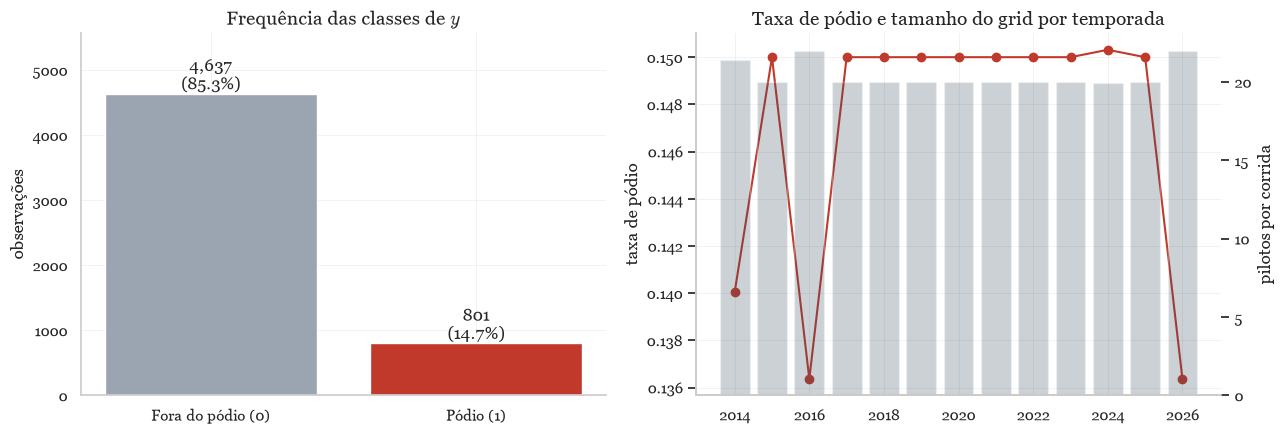

Proporção de pódios: 14.73%


In [6]:
# Distribuição da variável-alvo e tamanho do grid ao longo das temporadas.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

contagem = base_completa["podio"].value_counts().sort_index()
axes[0].bar(["Fora do pódio (0)", "Pódio (1)"], contagem.values, color=["#9aa5b1", "#c0392b"])
for i, v in enumerate(contagem.values):
    axes[0].text(i, v, f"{v:,}\n({v / contagem.sum():.1%})", ha="center", va="bottom")
axes[0].set_title("Frequência das classes de $y$")
axes[0].set_ylabel("observações")
axes[0].set_ylim(0, contagem.max() * 1.2)

por_ano = base_completa.groupby("ano").agg(pilotos=("podio", "size"), corridas=("raceId", "nunique"),
                                           taxa_podio=("podio", "mean"))
por_ano["pilotos_por_corrida"] = por_ano["pilotos"] / por_ano["corridas"]
axes[1].plot(por_ano.index, por_ano["taxa_podio"], marker="o", color="#c0392b", label="taxa de pódio")
axes[1].set_ylabel("taxa de pódio")
ax2 = axes[1].twinx()
ax2.bar(por_ano.index, por_ano["pilotos_por_corrida"], alpha=0.25, color="#34495e", label="pilotos por corrida")
ax2.set_ylabel("pilotos por corrida")
ax2.grid(False)
axes[1].set_title("Taxa de pódio e tamanho do grid por temporada")
plt.tight_layout()
plt.show()

print(f"Proporção de pódios: {base_completa['podio'].mean():.2%}")

<br>

---

<br>

### **Exercício 2 — Data wrangling e análise exploratória — 1,5 ponto**

Prepare a base para a etapa de modelagem. Toda transformação deve ser justificada e documentada.

1. **Diagnóstico de qualidade — 0,30 ponto.** Verifique tipos de dados, valores ausentes, duplicidades, categorias inconsistentes, valores impossíveis e outras anomalias relevantes.
2. **Tratamento dos dados — 0,40 ponto.** Execute o data wrangling necessário. Explique o que foi alterado, removido, imputado, convertido ou recodificado e por quê. Não remova observações ou variáveis apenas para melhorar métricas.
3. **Análise exploratória — 0,50 ponto.** Produza gráficos coerentes com o problema e interprete o que eles mostram sobre $\mathbf{X}$ e $\mathbf{y}$. A análise deve conter pelo menos três visualizações úteis ao desenvolvimento do modelo.
4. **Base final — 0,30 ponto.** Apresente as dimensões da base após o tratamento, verifique novamente ausências e duplicidades e registre quais decisões de preparação ainda precisarão ocorrer dentro do pipeline de modelagem.

**Sugestões de gráficos:** distribuição da variável-alvo; barras de valores ausentes; boxplots ou histogramas para variáveis numéricas; contagens para variáveis categóricas; matriz de correlação quando fizer sentido; relação entre variáveis importantes e o alvo.

<div style="border-left: 4px solid #666; padding: 10px 16px; margin: 18px 0;">
<strong>Atenção:</strong> qualquer transformação que aprenda parâmetros dos dados, como imputação baseada em estatísticas da amostra ou codificação aprendida, deve ser ajustada sem acesso ao conjunto de teste. Quando aplicável, faça essas etapas dentro de um pipeline.
</div>

**Resposta do aluno — Exercício 2**

O diagnóstico é feito sobre a tabela bruta de resultados da era híbrida (antes de qualquer tratamento). Os tratamentos estão implementados em `f1_pipeline.build_dataset` (arquivo compartilhado com a aplicação) e são explicados e verificados abaixo.

#### 2.1 Diagnóstico de qualidade

In [7]:
# Resposta do aluno - exercício 2
# Diagnóstico sobre a tabela bruta de resultados da era híbrida.
colunas_brutas = [c for c in tabelas["races-race-results"].columns]
diag = pd.DataFrame({
    "tipo": bruto[colunas_brutas].dtypes.astype(str),
    "ausentes": bruto[colunas_brutas].isna().sum(),
    "% ausentes": (bruto[colunas_brutas].isna().mean() * 100).round(1),
    "valores únicos": bruto[colunas_brutas].nunique(),
})
display(diag)

print("Duplicidades de linha inteira:", bruto.duplicated().sum())
print("Duplicidades de (corrida, piloto):", bruto.duplicated(["raceId", "driverId"]).sum())

,tipo,ausentes,% ausentes,valores únicos
raceId,int64,0,0.0,267
year,int64,0,0.0,13
round,int64,0,0.0,24
positionDisplayOrder,int64,0,0.0,22
positionNumber,float64,834,15.3,22
positionText,str,0,0.0,27
driverNumber,int64,0,0.0,55
driverId,str,0,0.0,63
constructorId,str,0,0.0,24
engineManufacturerId,str,0,0.0,11


Duplicidades de linha inteira: 0
Duplicidades de (corrida, piloto): 0


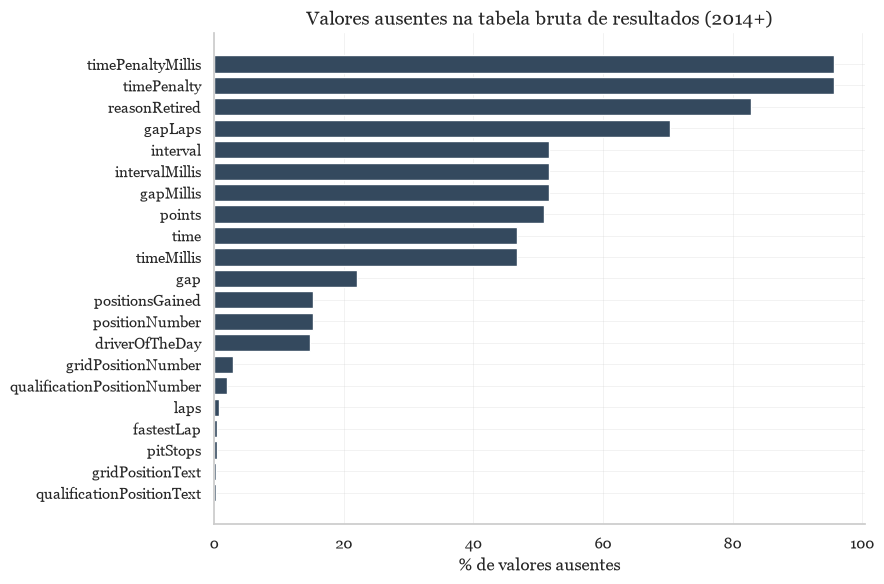

In [8]:
# Visualização das ausências por coluna.
ausentes = diag.loc[diag["ausentes"] > 0, "% ausentes"].sort_values()
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(ausentes.index, ausentes.values, color="#34495e")
ax.set_xlabel("% de valores ausentes")
ax.set_title("Valores ausentes na tabela bruta de resultados (2014+)")
plt.tight_layout()
plt.show()

In [9]:
# Códigos não numéricos em colunas de posição e colunas com tipos misturados.
def codigos_nao_numericos(serie):
    s = serie.astype("string")
    return s[~s.str.fullmatch(r"\d+").fillna(False)].fillna("<ausente>").value_counts().to_dict()

for col in ["positionText", "gridPositionText", "qualificationPositionText"]:
    print(f"{col:28s} -> {codigos_nao_numericos(bruto[col])}")

for col in ["fastestLap", "driverOfTheDay"]:
    tipos = bruto[col].map(lambda v: type(v).__name__).value_counts().to_dict()
    print(f"{col:28s} -> tipos misturados: {tipos}")

# Valores impossíveis: posições fora do intervalo físico do grid e pontos negativos.
print("\nGrid fora de [1, 26]:", ((bruto["gridPositionNumber"] < 1) | (bruto["gridPositionNumber"] > 26)).sum())
print("Classificação fora de [1, 26]:", ((bruto["qualificationPositionNumber"] < 1) |
                                        (bruto["qualificationPositionNumber"] > 26)).sum())
print("Pontos negativos:", (bruto["points"] < 0).sum())
print("Mais de 3 pódios na mesma corrida:", (bruto.assign(p=bruto["positionNumber"] <= 3)
                                             .groupby("raceId")["p"].sum() > 3).sum())

positionText                 -> {'DNF': 767, 'DNS': 44, 'DSQ': 18, 'NC': 3, 'DNP': 2}
gridPositionText             -> {'PL': 140, '<ausente>': 15}
qualificationPositionText    -> {'NC': 69, '<ausente>': 17, 'DSQ': 9, 'EX': 6, 'DNF': 3, 'DNS': 1}
fastestLap                   -> tipos misturados: {'bool': 5418, 'float': 20}
driverOfTheDay               -> tipos misturados: {'bool': 4631, 'float': 807}

Grid fora de [1, 26]: 0
Classificação fora de [1, 26]: 0
Pontos negativos: 0
Mais de 3 pódios na mesma corrida: 0


In [10]:
# Categorias inconsistentes: a mesma equipe/motor aparece com nomes diferentes ao longo dos anos.
equipes = (bruto.groupby("constructorId")["year"].agg(["min", "max"])
           .assign(linhagem=lambda d: d.index.map(lambda c: f1.TEAM_LINEAGE.get(c, c)))
           .sort_values(["linhagem", "min"]))
display(equipes[equipes["linhagem"].duplicated(keep=False)])

motores = (bruto.groupby("engineManufacturerId")["year"].agg(["min", "max"])
           .assign(fabricante_real=lambda d: d.index.map(lambda m: f1.ENGINE_NORMALIZE.get(m, m))))
display(motores[motores.index != motores["fabricante_real"]])

,min,max,linhagem
constructorId,,,
lotus-f1,2014,2015,alpine
renault,2016,2020,alpine
alpine,2021,2026,alpine
force-india,2014,2018,aston-martin
racing-point,2019,2020,aston-martin
aston-martin,2021,2026,aston-martin
marussia,2014,2015,manor
manor,2016,2016,manor
toro-rosso,2014,2019,racing-bulls


,min,max,fabricante_real
engineManufacturerId,,,
bwt-mercedes,2019,2020,mercedes
honda-rbpt,2023,2025,honda
rbpt,2022,2022,honda
tag-heuer,2016,2018,renault
toro-rosso,2017,2017,renault


**Achados do diagnóstico:**

- **Tipos de dados:** as colunas numéricas estão corretas. Há colunas textuais que misturam posição e código (`positionText`, `gridPositionText`, `qualificationPositionText`), e `fastestLap`/`driverOfTheDay` misturam `bool` e `float` (valores ausentes em anos em que o prêmio "piloto do dia" não existia). Todas essas colunas são pós-corrida e serão descartadas no Exercício 3.
- **Valores ausentes:** a maior parte das ausências está em colunas de **resultado** (tempo, gap, pontos, motivo do abandono), que só existem depois da corrida e têm ausência estrutural (quem abandona não tem tempo final). Nas colunas pré-corrida, as ausências são pequenas: `gridPositionNumber` (2,9%) e `qualificationPositionNumber` (1,9%).
- **Códigos especiais:** no grid, `PL` = largada do **pit lane** (140 casos, sem número de posição) e 15 pilotos sem grid (não largaram). No resultado, `DNF` (abandono), `DNS` (não largou), `DSQ` (desclassificado), `NC` (não classificado) e `DNP` (não participou). Na classificação, `NC`/`DSQ`/`EX` indicam piloto sem tempo válido.
- **Duplicidades:** nenhuma, nem de linha inteira nem do par (corrida, piloto).
- **Valores impossíveis:** nenhuma posição fora de [1, 26], nenhum ponto negativo e nenhuma corrida com mais de 3 pódios. A base oficial é consistente.
- **Categorias inconsistentes:** esta é a principal anomalia. A mesma equipe aparece com **nomes diferentes** ao longo dos anos (por exemplo, Force India → Racing Point → Aston Martin; Sauber → Alfa Romeo → Kick Sauber → Audi), e o mesmo motor aparece **rebatizado por patrocínio** (TAG Heuer e "Toro Rosso" em 2017 eram motores Renault; BWT-Mercedes era Mercedes; RBPT era Honda). Sem tratamento, o modelo trataria como entidades distintas estruturas que são a mesma fábrica.

#### 2.2 Tratamento dos dados

In [11]:
# Efeito dos tratamentos implementados em f1_pipeline.build_dataset.
print(f"Equipes: {bruto['constructorId'].nunique()} nomes -> {base_completa['equipe'].nunique()} linhagens")
print(f"Motores: {bruto['engineManufacturerId'].nunique()} nomes -> {base_completa['motor'].nunique()} fabricantes")
print(f"Largadas do pit lane recodificadas: {base_completa['largada_pit_lane'].sum()}")

# Pilotos sem posição de largada: não largaram (DNS/DNP) ou abandonaram antes da largada.
sem_grid = base_completa[base_completa["grid"].isna()]
display(sem_grid[["date", "driverId", "positionText", "gridPositionText"]])

base = base_completa[base_completa["grid"].notna()].reset_index(drop=True)
print(f"Linhas removidas (não largaram): {len(sem_grid)} | base após tratamento: {base.shape}")

Equipes: 24 nomes -> 13 linhagens
Motores: 11 nomes -> 6 fabricantes
Largadas do pit lane recodificadas: 140


,date,driverId,positionText,gridPositionText
23097,2015-03-15,valtteri-bottas,DNS,NaN
23098,2015-03-15,will-stevens,DNP,NaN
23099,2015-03-15,roberto-merhi,DNP,NaN
25301,2020-08-30,carlos-sainz-jr,DNS,NaN
25601,2021-05-23,charles-leclerc,DNS,NaN
25780,2021-09-12,pierre-gasly,DNF,NaN
25941,2021-12-12,nikita-mazepin,DNS,NaN
25980,2022-03-27,yuki-tsunoda,DNS,NaN
25981,2022-03-27,mick-schumacher,DNS,NaN
26661,2023-09-03,yuki-tsunoda,DNS,NaN


Linhas removidas (não largaram): 15 | base após tratamento: (5423, 49)


In [12]:
# Verificação de ausência de vazamento temporal nas variáveis de histórico:
# os valores "antes" de uma corrida devem refletir apenas corridas anteriores.
exemplo = base_completa.query("driverId == 'max-verstappen' and ano == 2023").head(6)
display(exemplo[["etapa", "circuito", "positionText", "podio", "pontos_piloto_antes",
                 "posicao_piloto_antes", "podios_piloto_ult5", "largadas_carreira"]])

,etapa,circuito,positionText,podio,pontos_piloto_antes,posicao_piloto_antes,podios_piloto_ult5,largadas_carreira
26382,1,bahrain,1,1,0.0,NaN,4.0,163
26403,2,jeddah,2,1,25.0,1.0,4.0,164
26422,3,melbourne,1,1,44.0,1.0,4.0,165
26443,4,baku,2,1,69.0,1.0,4.0,166
26462,5,miami,1,1,93.0,1.0,5.0,167
26482,6,monaco,1,1,119.0,1.0,5.0,168


**Tratamentos realizados e justificativas:**

| Tratamento | O que foi feito | Por quê |
|---|---|---|
| Recorte temporal | Mantidas as temporadas de 2014 em diante | Regras, confiabilidade e pontuação comparáveis (era híbrida). Não foi feito para "melhorar a métrica". |
| Alvo | `podio = 1` se `positionNumber ≤ 3`; DSQ/DNF/NC contam como 0 | É o pódio oficial. Uma desclassificação tira o pódio. |
| Unificação de equipes | 24 nomes → 13 linhagens (`TEAM_LINEAGE`) | Mesma sede, fábrica e pessoal; a troca de nome é comercial. |
| Unificação de motores | 11 nomes → 6 fabricantes reais (`ENGINE_NORMALIZE`) | Nomes de patrocínio escondiam o fabricante real. |
| Largada do pit lane | `grid` = último lugar + 1 e indicador `largada_pit_lane` | O piloto larga atrás de todos; o valor ausente seria enganoso. |
| Pilotos que não largaram | 15 linhas removidas (DNS/DNP sem grid) | O modelo prevê o resultado de quem **larga**; essas linhas não têm posição de largada nem resultado de corrida. |
| Campeonato antes da corrida | Classificação **após a etapa anterior** do mesmo ano (`round + 1` no merge) | Usar a classificação após a própria corrida vazaria o resultado. Na 1ª etapa, pontos = 0 e a posição fica ausente (imputada no pipeline). |
| Forma recente | Pódios nas 5 corridas anteriores (piloto e equipe) e largadas na carreira, com `shift(1)` | O `shift` garante que só corridas passadas entrem. O histórico é calculado desde 1950 para que os dados de 2014 já tenham forma prévia. |

A tabela de exemplo (Verstappen, 2023) confirma a ausência de vazamento temporal: na 1ª etapa os pontos antes da corrida são 0; na 2ª etapa aparecem os 25 pontos da vitória anterior; e a posição no campeonato e os pódios recentes só mudam depois de cada corrida.

#### 2.3 Análise exploratória

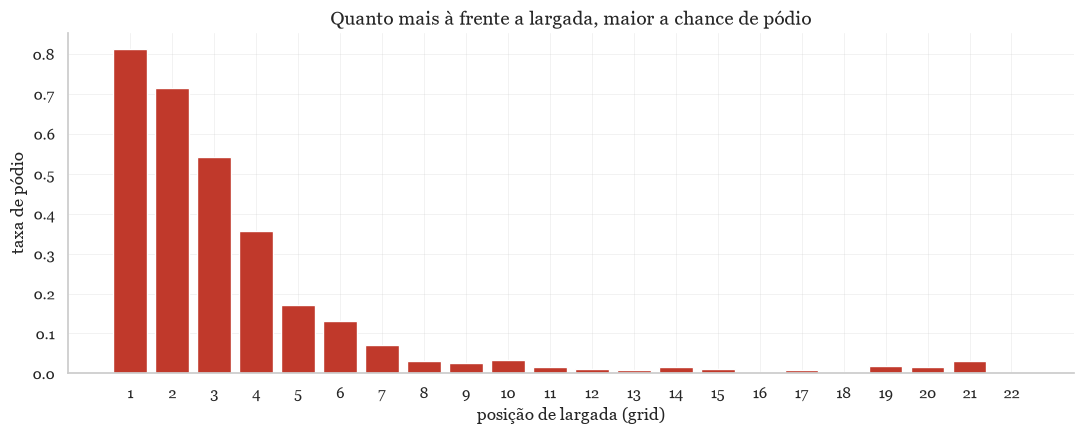

grid,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0
mean,0.812,0.714,0.543,0.356,0.172,0.131,0.072,0.03
size,266.000,266.000,267.000,267.000,267.000,267.000,265.000,266.00


In [13]:
# Gráfico 1 - Taxa de pódio por posição de largada.
taxa_grid = base.groupby("grid")["podio"].agg(["mean", "size"])
taxa_grid = taxa_grid[taxa_grid["size"] >= 30]
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(taxa_grid.index.astype(int), taxa_grid["mean"], color="#c0392b")
ax.set_xticks(taxa_grid.index.astype(int))
ax.set_xlabel("posição de largada (grid)")
ax.set_ylabel("taxa de pódio")
ax.set_title("Quanto mais à frente a largada, maior a chance de pódio")
plt.tight_layout()
plt.show()
display(taxa_grid.head(8).T.round(3))

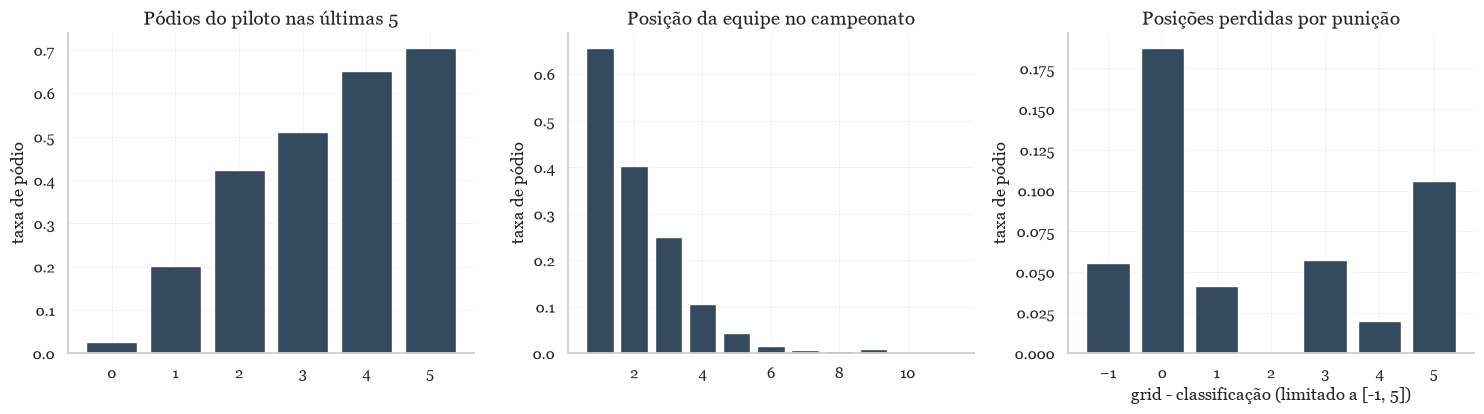

In [14]:
# Gráfico 2 - Forma recente e força da equipe versus o alvo.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
for ax, col, titulo in zip(
    axes,
    ["podios_piloto_ult5", "posicao_equipe_antes", "perda_grid"],
    ["Pódios do piloto nas últimas 5", "Posição da equipe no campeonato", "Posições perdidas por punição"],
):
    dados = f1.add_derived_features(base) if col == "perda_grid" else base
    if col == "perda_grid":
        dados = dados.assign(perda_grid=dados["perda_grid"].clip(-1, 5))
    taxa = dados.groupby(col)["podio"].agg(["mean", "size"])
    taxa = taxa[taxa["size"] >= 20]
    ax.bar(taxa.index.astype(int), taxa["mean"], color="#34495e")
    ax.set_title(titulo)
    ax.set_ylabel("taxa de pódio")
axes[2].set_xlabel("grid - classificação (limitado a [-1, 5])")
plt.tight_layout()
plt.show()

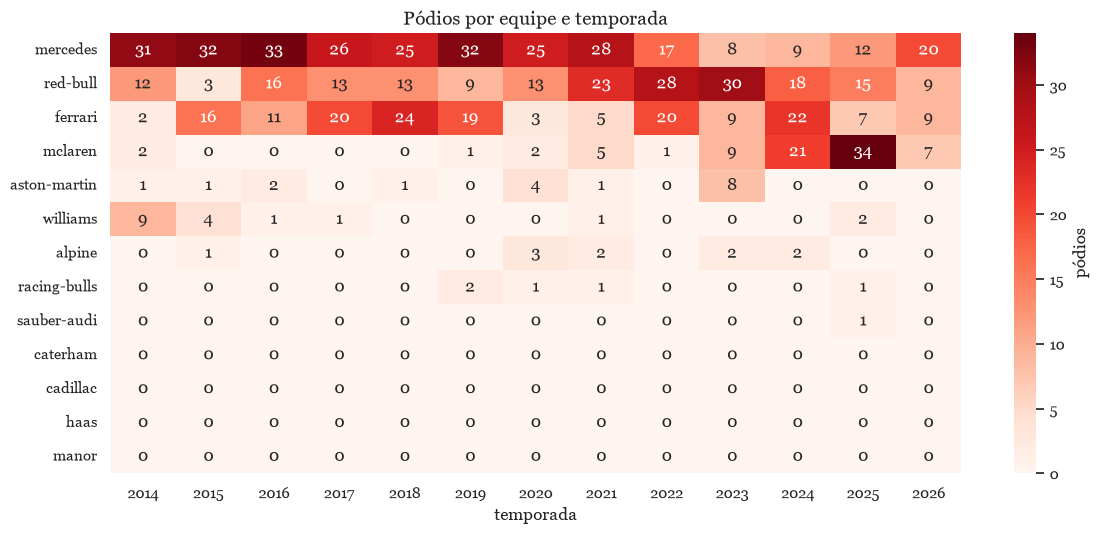

In [15]:
# Gráfico 3 - Pódios por equipe e temporada: eras de domínio.
podios_equipe = base.pivot_table(index="equipe", columns="ano", values="podio", aggfunc="sum", fill_value=0)
podios_equipe = podios_equipe.loc[podios_equipe.sum(axis=1).sort_values(ascending=False).index]
fig, ax = plt.subplots(figsize=(12, 5.5))
sns.heatmap(podios_equipe, annot=True, fmt="d", cmap="Reds", cbar_kws={"label": "pódios"}, ax=ax)
ax.set_title("Pódios por equipe e temporada")
ax.set_xlabel("temporada")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

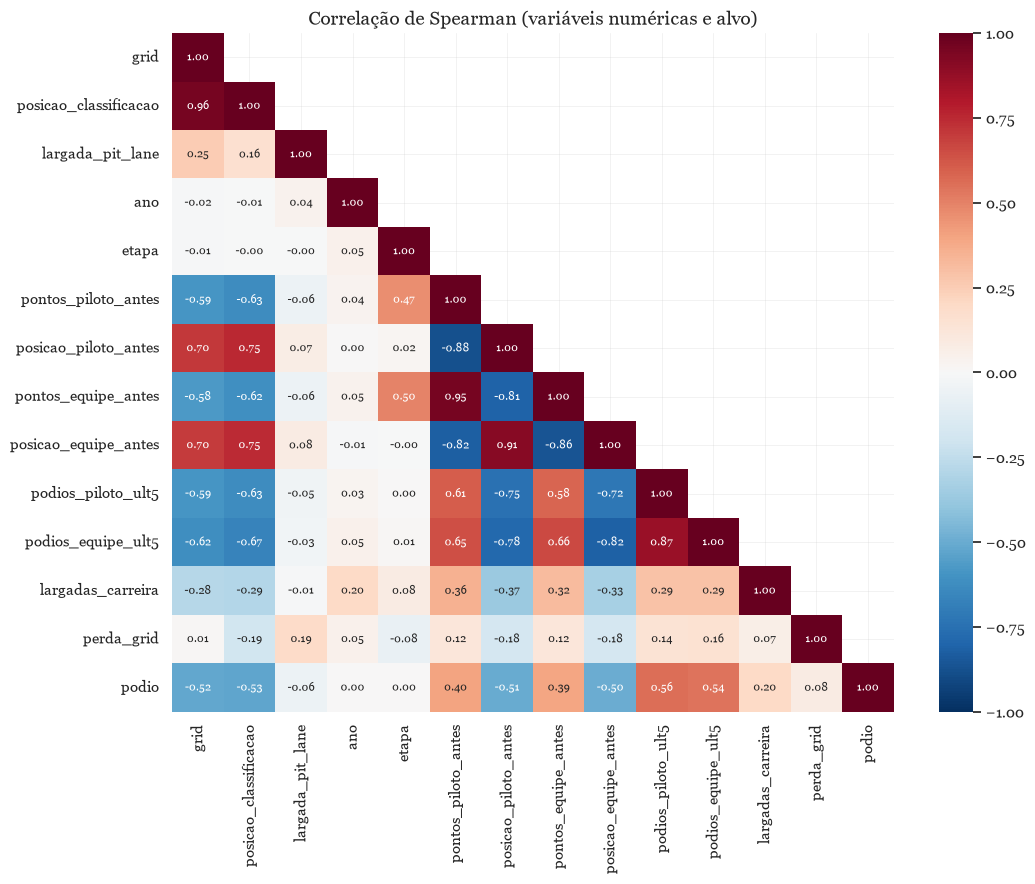

In [16]:
# Gráfico 4 - Correlação de Spearman entre variáveis numéricas e o alvo.
numericas = f1.add_derived_features(base)[f1.NUM_FEATURES + f1.DERIVED_FEATURES + ["podio"]]
corr = numericas.corr(method="spearman")
fig, ax = plt.subplots(figsize=(11, 9))
mascara = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mascara, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            annot_kws={"size": 8}, ax=ax)
ax.set_title("Correlação de Spearman (variáveis numéricas e alvo)")
plt.tight_layout()
plt.show()

**Interpretação da análise exploratória:**

1. **Posição de largada (gráfico 1):** é o fator dominante. A taxa de pódio cai de forma monotônica, de **81% (pole)** para 71% (2º), 54% (3º), 36% (4º) e 17% (5º), e fica abaixo de 3% a partir do 8º lugar. Isso explica por que a referência ingênua (ordenar só pelo grid) já atinge ROC-AUC ≈ 0,92. O desafio do modelo é ir **além** disso.
2. **Forma e força da equipe (gráfico 2):** um piloto sem pódios nas últimas 5 corridas sobe ao pódio só 2,7% das vezes, contra 70% para quem fez 5 em 5. A equipe líder do campeonato vai ao pódio em 66% das corridas por carro, e a 5ª colocada em apenas 4%. A perda de posições por punição (`perda_grid > 0`) reduz a taxa de pódio em relação a quem larga onde se classificou.
3. **Eras de domínio (gráfico 3):** o mapa mostra a hegemonia da Mercedes (2014–2021), a ascensão da Red Bull (2021–2023), a McLaren em 2024–2025 e a Ferrari como força constante. Isso justifica usar **equipe** e **pontos/posição da equipe antes da corrida**: a força relativa dos carros muda entre temporadas, e as variáveis de campeonato capturam essa mudança dentro de cada ano.
4. **Correlações (gráfico 4):** as variáveis mais associadas ao pódio são pódios recentes (ρ ≈ 0,55), posição na classificação e grid (ρ ≈ −0,53 e −0,52) e posição no campeonato (ρ ≈ −0,51). Há **forte colinearidade** entre grid e classificação (ρ ≈ 0,96) e entre pontos e posição no campeonato (ρ ≈ −0,88). Isso não prejudica modelos de árvore, mas deve ser lembrado ao interpretar importâncias, porque variáveis correlacionadas "dividem" a importância. `ano` e `etapa` quase não se correlacionam com o alvo (ρ ≈ 0).

#### 2.4 Base final

In [17]:
# Base final: dimensões, ausências remanescentes e duplicidades.
print(f"Dimensões finais: {base.shape[0]:,} linhas x {base.shape[1]} colunas")
print("Duplicidades de (corrida, piloto):", base.duplicated(["raceId", "driverId"]).sum())
print(f"Proporção de pódios: {base['podio'].mean():.2%}")
ausencias_finais = base[f1.FEATURES].isna().sum()
display(ausencias_finais[ausencias_finais > 0].rename("ausentes (tratados no pipeline)").to_frame())

Dimensões finais: 5,423 linhas x 49 colunas
Duplicidades de (corrida, piloto): 0
Proporção de pódios: 14.77%


,ausentes (tratados no pipeline)
posicao_classificacao,101
posicao_piloto_antes,361
posicao_equipe_antes,279


**Base final:** 5.423 observações × 16 variáveis preditoras + alvo, sem duplicidades, com 14,77% de pódios.

As ausências remanescentes são **informativas e estruturais**, não erros: `posicao_classificacao` (piloto sem tempo válido na classificação), `posicao_piloto_antes`/`posicao_equipe_antes` (1ª etapa da temporada ou estreia). Elas **não** foram imputadas aqui, porque a imputação aprende estatísticas da amostra e precisa ocorrer **dentro do pipeline**, ajustada apenas nos dados de treino de cada fold.

**Decisões que ocorrem dentro do pipeline** (`f1.make_pipeline`):
1. Cálculo da variável derivada `perda_grid = grid − posicao_classificacao` (posições perdidas por punição);
2. Imputação das numéricas pela **mediana** do treino, com **indicadores de ausência** (`add_indicator=True`), para que o modelo saiba que a informação faltava;
3. Imputação das categóricas pela moda e **one-hot encoding** com `handle_unknown="ignore"` (uma equipe nova, como a Cadillac, não quebra a previsão).

Como o mesmo objeto `Pipeline` é salvo e carregado pela aplicação Streamlit, a preparação em produção é idêntica à do notebook.

<br>

---

<br>

### **Exercício 3 — Escolha de variáveis e desenho experimental — 1,0 ponto**

Defina formalmente o conjunto de variáveis utilizado na modelagem e estabeleça o protocolo experimental antes de treinar os algoritmos.

1. **Escolha das variáveis — 0,35 ponto.** Defina $\mathbf{X}$ e $\mathbf{y}$. Liste variáveis removidas e justifique a exclusão. Identificadores, informações disponíveis apenas depois do evento previsto e variáveis que revelem diretamente o alvo devem ser analisados como possíveis fontes de **data leakage**.
2. **Separação treino–teste e validação cruzada — 0,35 ponto.** Construa $\mathcal{D}_{\mathrm{treino}}$ e $\mathcal{D}_{\mathrm{teste}}$ com uma proporção adequada e `random_state` fixo. Em classificação, utilize estratificação quando aplicável. Defina o esquema de validação cruzada que será usado dentro de $\mathcal{D}_{\mathrm{treino}}$.
3. **Métricas — 0,30 ponto.** Registre a métrica principal e as métricas auxiliares. Explique por que elas são adequadas ao problema e como serão interpretadas.

**Referência de decisão:** para classificação, considere o balanceamento das classes ao escolher entre acurácia, precision, recall, F1, ROC-AUC ou outras métricas pertinentes. Para regressão, considere métricas como MAE, RMSE e $R^2$. A escolha deve ser justificada e mantida de forma consistente ao comparar os modelos.

<div style="border-left: 4px solid #666; padding: 10px 16px; margin: 18px 0;">
<strong>Regra experimental:</strong> os três algoritmos devem utilizar o mesmo conjunto de teste e, sempre que possível, os mesmos folds de validação cruzada e a mesma métrica principal. O conjunto de teste não pode participar do Grid Search, do Optuna ou da escolha do melhor modelo.
</div>

**Resposta do aluno — Exercício 3**

**1. Escolha das variáveis.** $\mathbf{X}$ contém 16 variáveis, todas **conhecidas antes da largada**:
- **Numéricas (12):** `grid`, `posicao_classificacao`, `largada_pit_lane`, `ano`, `etapa`, `pontos_piloto_antes`, `posicao_piloto_antes`, `pontos_equipe_antes`, `posicao_equipe_antes`, `podios_piloto_ult5`, `podios_equipe_ult5`, `largadas_carreira`;
- **Categóricas (4):** `equipe`, `motor`, `circuito`, `tipo_circuito`.

$\mathbf{y}$ = `podio`.

**Análise de data leakage.** A tabela de resultados tem **20 colunas que só existem depois da corrida**: posição final, voltas, tempo, gap, intervalo, pontos, motivo do abandono, posições ganhas, número de pit stops, volta mais rápida, piloto do dia e grand slam. Todas foram removidas. Algumas revelam o alvo diretamente (`positionNumber`, `points`: quem pontua 15+ está no pódio), e outras o revelam indiretamente (`positionsGained`, `gap`, `reasonRetired`: quem abandonou não pode estar no pódio). Um modelo que as usasse teria desempenho quase perfeito no notebook e seria inútil antes da largada.

**Identificadores.** `raceId`, `driverId` e `driverNumber` foram excluídos: permitiriam ao modelo "decorar" pilotos (por exemplo, "Hamilton = pódio") em vez de aprender padrões que generalizam para novos pilotos e temporadas. A qualidade do piloto entra de forma legítima pelo campeonato e pela forma recente. Também foram removidas colunas redundantes (`polePosition`, versões textuais das posições) e constantes na era híbrida (`tyreManufacturerId` = Pirelli, `sharedCar` = False).

**Leakage temporal nas variáveis construídas:** todas as variáveis de histórico usam apenas corridas anteriores (etapa anterior para o campeonato e `shift(1)` para forma e experiência), como verificado no Exercício 2.

In [18]:
# Resposta do aluno - exercício 3
# Definição de X e y.
X = base[f1.FEATURES]
y = base[f1.TARGET]
print(f"X: {X.shape} | y: {y.shape}")
print("Variáveis numéricas:", f1.NUM_FEATURES)
print("Variáveis categóricas:", f1.CAT_FEATURES)

removidas = pd.DataFrame(
    [(c, "data leakage: informação disponível apenas depois da corrida") for c in f1.LEAKAGE_COLUMNS]
    + [
        ("raceId, driverId, driverNumber", "identificadores: não generalizam e permitem memorizar o piloto"),
        ("constructorId, engineManufacturerId", "substituídas por equipe/motor com categorias unificadas"),
        ("gridPositionText, qualificationPositionText", "versões textuais já convertidas em grid/posicao_classificacao"),
        ("polePosition", "redundante com posicao_classificacao == 1"),
        ("tyreManufacturerId, sharedCar", "constantes na era híbrida (Pirelli, sem carros compartilhados)"),
        ("date", "substituída por ano e etapa"),
    ],
    columns=["variável removida", "motivo"],
)
display(removidas)
print("Valores únicos de tyreManufacturerId e sharedCar:",
      bruto["tyreManufacturerId"].unique().tolist(), bruto["sharedCar"].unique().tolist())

X: (5423, 16) | y: (5423,)
Variáveis numéricas: ['grid', 'posicao_classificacao', 'largada_pit_lane', 'ano', 'etapa', 'pontos_piloto_antes', 'posicao_piloto_antes', 'pontos_equipe_antes', 'posicao_equipe_antes', 'podios_piloto_ult5', 'podios_equipe_ult5', 'largadas_carreira']
Variáveis categóricas: ['equipe', 'motor', 'circuito', 'tipo_circuito']


,variável removida,motivo
0,positionDisplayOrder,data leakage: informação disponível apenas dep...
1,positionNumber,data leakage: informação disponível apenas dep...
2,positionText,data leakage: informação disponível apenas dep...
3,laps,data leakage: informação disponível apenas dep...
4,time,data leakage: informação disponível apenas dep...
5,timeMillis,data leakage: informação disponível apenas dep...
6,timePenalty,data leakage: informação disponível apenas dep...
7,timePenaltyMillis,data leakage: informação disponível apenas dep...
8,gap,data leakage: informação disponível apenas dep...
9,gapMillis,data leakage: informação disponível apenas dep...


Valores únicos de tyreManufacturerId e sharedCar: ['pirelli'] [False]


In [19]:
# Separação treino-teste estratificada e protocolo de validação cruzada.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)
cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

display(pd.DataFrame({
    "linhas": [len(X_train), len(X_test)],
    "pódios": [y_train.sum(), y_test.sum()],
    "proporção de pódios": [y_train.mean(), y_test.mean()],
}, index=["D_treino", "D_teste"]).round(4))

# Os mesmos folds serão usados por todos os modelos (cv com semente fixa).
for k, (_, idx_val) in enumerate(cv.split(X_train, y_train), start=1):
    print(f"fold {k}: {len(idx_val)} obs. de validação, {y_train.iloc[idx_val].mean():.2%} de pódios")

,linhas,pódios,proporção de pódios
D_treino,4338,641,0.1478
D_teste,1085,160,0.1475


fold 1: 868 obs. de validação, 14.75% de pódios
fold 2: 868 obs. de validação, 14.75% de pódios
fold 3: 868 obs. de validação, 14.86% de pódios
fold 4: 867 obs. de validação, 14.76% de pódios
fold 5: 867 obs. de validação, 14.76% de pódios


In [20]:
# Métricas: principal (ROC-AUC) e auxiliares, todas calculadas nos mesmos folds.
METRICA_PRINCIPAL = "roc_auc"
SCORING = {
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
    "f1": "f1",
    "precision": "precision",
    "recall": "recall",
    "accuracy": "accuracy",
}

# Referência ingênua: ordenar pilotos apenas pela posição de largada (sem treinar nada).
auc_ingenuo = roc_auc_score(y_train, -X_train["grid"])
print(f"ROC-AUC da referência ingênua (apenas o grid) em D_treino: {auc_ingenuo:.4f}")
print(f"Acurácia de prever sempre 'fora do pódio': {1 - y_train.mean():.4f}")

ROC-AUC da referência ingênua (apenas o grid) em D_treino: 0.9230
Acurácia de prever sempre 'fora do pódio': 0.8522


**2. Particionamento.** $\mathcal{D}_{\mathrm{treino}}$ (80%, 4.338 obs.) e $\mathcal{D}_{\mathrm{teste}}$ (20%, 1.085 obs.), com **estratificação** por `podio` e `random_state=42`. A proporção de pódios ficou praticamente idêntica (14,78% × 14,75%). O teste fica isolado até o Exercício 7.

Validação cruzada: **`StratifiedKFold` com K = 5, embaralhado, `random_state=42`**, aplicada apenas em $\mathcal{D}_{\mathrm{treino}}$. O mesmo objeto `cv` é usado nos baselines, no Grid Search, no Optuna, na tabela final e na curva de aprendizado, o que garante que **todos os modelos são avaliados exatamente nos mesmos folds** (cada fold tem ~868 observações e ~14,8% de pódios).

*Observação metodológica:* como todas as variáveis foram construídas apenas com informação anterior à corrida, a divisão aleatória não introduz vazamento de resultado. Ela avalia a capacidade de generalizar para corridas não vistas **dentro** da era híbrida. Uma divisão temporal (treinar até 2024 e testar em 2025–2026) mediria outra coisa, a extrapolação para regulamentos futuros. Seguimos o protocolo estratificado pedido no enunciado e registramos isso como limitação.

**3. Métricas.**

| Métrica | Papel | Interpretação |
|---|---|---|
| **ROC-AUC** | **principal** | Probabilidade de um piloto que sobe ao pódio receber score maior que um que não sobe. Independe do limiar e da prevalência. 0,5 = aleatório. |
| Average Precision (PR-AUC) | auxiliar | Foca na classe rara (pódio). A linha de base é a prevalência (~0,15), então valores bem acima disso indicam boa identificação dos pódios. |
| F1, precision, recall | auxiliares | Dependem do limiar $\tau$. Precision: dos pilotos apontados como pódio, quantos subiram. Recall: dos pódios reais, quantos foram apontados. |
| Acurácia | auxiliar (com cautela) | O classificador trivial "ninguém sobe ao pódio" já tem 85,2%, então só é informativa acima desse patamar. |

**Referência ingênua:** ordenar os pilotos pela posição de largada, sem treinar nada, dá ROC-AUC = **0,923** em $\mathcal{D}_{\mathrm{treino}}$. Um modelo só agrega valor se superar esse número.

<br>

---

<br>

### **Exercício 4 — Implementação dos três modelos de referência — 1,5 ponto**

Implemente uma primeira versão comparável dos três algoritmos antes do tuning:

$$
M_{\mathrm{RF}},
\qquad
M_{\mathrm{XGB}},
\qquad
M_{\mathrm{LGBM}}.
$$

Utilize as classes de classificação ou regressão correspondentes ao problema escolhido.

1. **Random Forest — 0,30 ponto.** Treine um modelo de referência e registre os hiperparâmetros utilizados.
2. **XGBoost — 0,30 ponto.** Treine um modelo de referência sob o mesmo protocolo experimental.
3. **LightGBM — 0,30 ponto.** Treine um modelo de referência sob o mesmo protocolo experimental.
4. **Comparação inicial — 0,60 ponto.** Construa uma tabela única contendo, no mínimo, modelo, métrica no treino, média da validação cruzada, desvio-padrão da validação cruzada e tempo de treinamento. Interprete as diferenças observadas e identifique sinais iniciais de overfitting ou underfitting.

O objetivo desta etapa é criar um **baseline comparável**, não encontrar ainda o melhor conjunto de hiperparâmetros.

**Sugestões de gráficos:** barras com a média e dispersão dos scores de validação cruzada; comparação entre score de treino e score médio de validação; tempo de treinamento por modelo.

**Resposta do aluno — Exercício 4**

Os três baselines usam **exatamente o mesmo pipeline de preparação** (`f1.make_pipeline`), os mesmos folds e a mesma métrica. Só o estimador muda, com os **hiperparâmetros padrão** de cada biblioteca (fixando apenas `random_state=42` e paralelismo). O XGBoost omite os valores padrão em `get_params()` (aparecem como `None`). Os valores efetivos da versão 3.x são `n_estimators=100`, `max_depth=6`, `learning_rate=0.3`, `subsample=1`, `colsample_bytree=1` e `min_child_weight=1`. A "métrica no treino" é a ROC-AUC média nos folds de treino da validação cruzada.

In [21]:
# Resposta do aluno - exercício 4
# Fábricas de estimadores: parâmetros fixos (semente, paralelismo) + hiperparâmetros θ variáveis.
FABRICAS = {
    "Random Forest": lambda **p: RandomForestClassifier(random_state=SEED, n_jobs=-1, **p),
    "XGBoost": lambda **p: XGBClassifier(random_state=SEED, n_jobs=-1, eval_metric="logloss", **p),
    "LightGBM": lambda **p: LGBMClassifier(random_state=SEED, n_jobs=-1, verbose=-1, subsample_freq=1, **p),
}
MODELOS = list(FABRICAS)


def avaliar_cv(modelo, configuracao, params=None):
    """Validação cruzada com os folds do protocolo; retorna métricas de treino e validação."""
    pipe = f1.make_pipeline(FABRICAS[modelo](**(params or {})))
    res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=SCORING, return_train_score=True)
    linha = {
        "modelo": modelo,
        "configuração": configuracao,
        "AUC treino": res["train_roc_auc"].mean(),
        "AUC CV média": res["test_roc_auc"].mean(),
        "AUC CV dp": res["test_roc_auc"].std(),
    }
    linha["gap (treino - CV)"] = linha["AUC treino"] - linha["AUC CV média"]
    for m in ["average_precision", "f1", "precision", "recall", "accuracy"]:
        linha[f"{m} CV"] = res[f"test_{m}"].mean()
    linha["tempo de treino por fold (s)"] = res["fit_time"].mean()
    return linha, res


XGB_PADROES = {"n_estimators": 100, "max_depth": 6, "learning_rate": 0.3, "subsample": 1.0,
               "colsample_bytree": 1.0, "min_child_weight": 1.0}
PARAMS_REGISTRO = {
    "Random Forest": ["n_estimators", "max_depth", "min_samples_leaf", "max_features"],
    "XGBoost": ["n_estimators", "max_depth", "learning_rate", "subsample", "colsample_bytree", "min_child_weight"],
    "LightGBM": ["n_estimators", "num_leaves", "max_depth", "learning_rate", "min_child_samples", "subsample"],
}

In [22]:
# Baselines: hiperparâmetros padrão de cada biblioteca, mesmo pipeline e mesmos folds.
linhas_baseline, cv_baseline = [], {}
for modelo in MODELOS:
    linha, res = avaliar_cv(modelo, "baseline")
    linhas_baseline.append(linha)
    cv_baseline[modelo] = res
    params = FABRICAS[modelo]().get_params()
    # O XGBoost expõe None nos parâmetros não informados; registramos os padrões efetivos da versão 3.x.
    if modelo == "XGBoost":
        params = {k: (XGB_PADROES.get(k) if v is None else v) for k, v in params.items()}
    print(f"{modelo:14s} θ = { {k: params[k] for k in PARAMS_REGISTRO[modelo]} }")

tabela_baseline = pd.DataFrame(linhas_baseline).set_index("modelo")
colunas_principais = ["AUC treino", "AUC CV média", "AUC CV dp", "gap (treino - CV)",
                      "average_precision CV", "f1 CV", "tempo de treino por fold (s)"]
display(tabela_baseline[colunas_principais].round(4))
print(f"Referência ingênua (apenas grid): {auc_ingenuo:.4f}")

Random Forest  θ = {'n_estimators': 100, 'max_depth': None, 'min_samples_leaf': 1, 'max_features': 'sqrt'}


XGBoost        θ = {'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.3, 'subsample': 1.0, 'colsample_bytree': 1.0, 'min_child_weight': 1.0}


LightGBM       θ = {'n_estimators': 100, 'num_leaves': 31, 'max_depth': -1, 'learning_rate': 0.1, 'min_child_samples': 20, 'subsample': 1.0}


,AUC treino,AUC CV média,AUC CV dp,gap (treino - CV),average_precision CV,f1 CV,tempo de treino por fold (s)
modelo,,,,,,,
Random Forest,1.0000,0.9366,0.0111,0.0634,0.7049,0.6638,0.2941
XGBoost,1.0000,0.9252,0.0130,0.0748,0.6821,0.6618,0.2195
LightGBM,0.9999,0.9317,0.0109,0.0682,0.6871,0.6481,0.2786


Referência ingênua (apenas grid): 0.9230


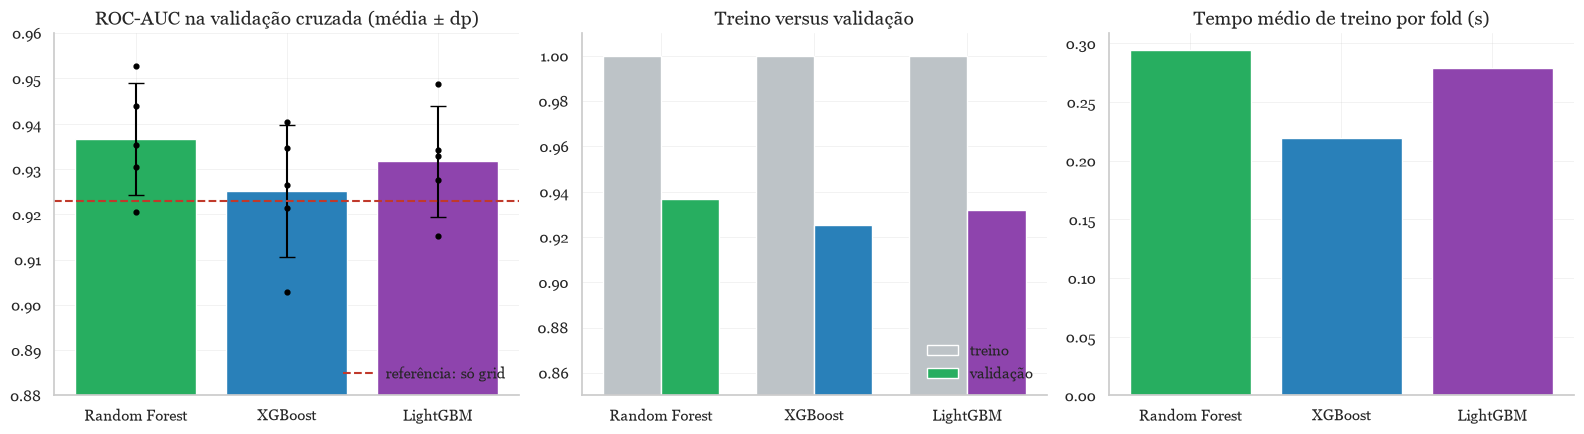

In [23]:
# Visualizações da comparação inicial.
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
cores = ["#27ae60", "#2980b9", "#8e44ad"]

scores_folds = pd.DataFrame({m: cv_baseline[m]["test_roc_auc"] for m in MODELOS})
axes[0].bar(MODELOS, scores_folds.mean(), yerr=scores_folds.std(), capsize=6, color=cores)
for i, m in enumerate(MODELOS):
    axes[0].scatter([i] * N_FOLDS, scores_folds[m], color="black", s=12, zorder=3)
axes[0].axhline(auc_ingenuo, ls="--", color="#c0392b", label="referência: só grid")
axes[0].set_ylim(0.88, 0.96)
axes[0].set_title("ROC-AUC na validação cruzada (média ± dp)")
axes[0].legend(loc="lower right")

largura = 0.38
pos = np.arange(len(MODELOS))
axes[1].bar(pos - largura / 2, tabela_baseline["AUC treino"], largura, label="treino", color="#bdc3c7")
axes[1].bar(pos + largura / 2, tabela_baseline["AUC CV média"], largura, label="validação", color=cores)
axes[1].set_xticks(pos, MODELOS)
axes[1].set_ylim(0.85, 1.01)
axes[1].set_title("Treino versus validação")
axes[1].legend(loc="lower right")

axes[2].bar(MODELOS, tabela_baseline["tempo de treino por fold (s)"], color=cores)
axes[2].set_title("Tempo médio de treino por fold (s)")
plt.tight_layout()
plt.show()

**Interpretação da comparação inicial:**

- **Desempenho:** os três baselines superam a referência ingênua (0,923). O Random Forest teve a maior média de validação (**0,937**), seguido do LightGBM (0,932) e do XGBoost (0,925). As diferenças entre eles, porém, são do tamanho do desvio-padrão entre folds (~0,011), então **ainda não há vencedor claro**.
- **Sinal forte de overfitting:** os três atingem **ROC-AUC ≈ 1,000 no treino**, com gap de 0,06–0,07 para a validação. Com os padrões das bibliotecas, as árvores crescem sem restrição (RF com `max_depth=None` e `min_samples_leaf=1`; XGBoost com profundidade 6 e taxa de aprendizado 0,3; LightGBM com 31 folhas) e **memorizam** o treino. Isso é esperado em uma base de ~4 mil linhas com um sinal dominante (o grid) e muito ruído (acidentes e quebras que nenhuma variável pré-corrida prevê).
- **Underfitting:** não há sinal. Todos superam a referência e capturam informação além do grid.
- **Custo:** os três treinam em fração de segundo por fold. O LightGBM e o XGBoost são os mais rápidos, e o Random Forest é o mais lento, por treinar 100 árvores profundas completas.

**Conclusão:** o espaço para ganho está em **controlar a complexidade** (profundidade, folhas, tamanho mínimo das folhas, taxa de aprendizado e regularização), que é justamente o foco do tuning no Exercício 5.

<br>

---

<br>

### **Exercício 5 — Tuning com Grid Search e Optuna — 2,0 pontos**

Ajuste os hiperparâmetros de **cada um dos três modelos** usando duas estratégias distintas: Grid Search e Optuna. Todo tuning deve ocorrer exclusivamente sobre $\mathcal{D}_{\mathrm{treino}}$ e utilizar o protocolo de validação definido no Exercício 3.

O problema geral pode ser representado como a busca por um conjunto de hiperparâmetros $\boldsymbol{\theta}$ que otimiza a métrica de validação cruzada:

$$
\boldsymbol{\theta}^{\star}
=
\operatorname*{arg\,opt}_{\boldsymbol{\theta}\in\Theta}
\frac{1}{K}
\sum_{k=1}^{K}
S_k(\boldsymbol{\theta}),
$$

em que $\operatorname*{arg\,opt}$ significa maximizar uma métrica de desempenho ou minimizar uma função de erro, conforme a métrica principal adotada.

1. **Grid Search — 0,75 ponto.** Para $M_{\mathrm{RF}}$, $M_{\mathrm{XGB}}$ e $M_{\mathrm{LGBM}}$, defina uma grade coerente de hiperparâmetros, execute a busca e registre os melhores parâmetros, o score médio de validação e o custo computacional. A grade deve explorar parâmetros que controlem complexidade, número de árvores e/ou taxa de aprendizado, conforme o algoritmo.
2. **Optuna — 1,00 ponto.** Para os três modelos, defina uma função objetivo baseada na mesma métrica principal e nos mesmos dados de validação. Documente o espaço de busca, o número de trials e o melhor conjunto de hiperparâmetros. Como referência, utilize pelo menos 20 trials por modelo ou justifique claramente uma quantidade menor por restrição computacional.
3. **Comparação das estratégias — 0,25 ponto.** Compare Grid Search e Optuna em qualidade da solução, custo computacional e comportamento da busca. Não escolha uma estratégia apenas porque produziu um número ligeiramente melhor; discuta estabilidade e complexidade.

**Sugestões de gráficos:** curva ou mapa de scores do `cv_results_` do Grid Search para hiperparâmetros relevantes; histórico de otimização do Optuna; importância dos hiperparâmetros no Optuna; tempo de busca por modelo e estratégia.

<div style="border-left: 4px solid #666; padding: 10px 16px; margin: 18px 0;">
<strong>Controle de comparabilidade:</strong> mantenha a métrica principal, a preparação dos dados e o esquema de validação tão consistentes quanto possível entre os três modelos. Se houver diferença de pipeline necessária por causa de uma biblioteca ou tipo de variável, explique a diferença e por que ela não invalida a comparação.
</div>

**Resposta do aluno — Exercício 5**

Todo o tuning usa somente $\mathcal{D}_{\mathrm{treino}}$, o mesmo pipeline, os mesmos 5 folds e a mesma métrica (ROC-AUC, maximizada):

$$\boldsymbol{\theta}^{\star} = \arg\max_{\boldsymbol{\theta}\in\Theta} \frac{1}{5}\sum_{k=1}^{5} \mathrm{AUC}_k(\boldsymbol{\theta}).$$

**Grid Search.** Grades com **24 combinações para cada modelo** (120 ajustes cada), para que o custo seja comparável. Elas exploram número de árvores, complexidade (profundidade, folhas, tamanho mínimo das folhas) e taxa de aprendizado:
- **RF:** `n_estimators` ∈ {200, 500}, `max_depth` ∈ {4, 8, 16, None}, `min_samples_leaf` ∈ {1, 5, 20};
- **XGBoost:** `n_estimators` ∈ {200, 500}, `max_depth` ∈ {2, 4, 6}, `learning_rate` ∈ {0,03; 0,1}, `subsample` ∈ {0,8; 1,0};
- **LightGBM:** `n_estimators` ∈ {200, 500}, `num_leaves` ∈ {7, 15, 31}, `learning_rate` ∈ {0,03; 0,1}, `min_child_samples` ∈ {20, 50}.

**Optuna.** Sampler **TPE** (`seed=42`) com **30 trials por modelo** (acima da referência de 20), em espaços contínuos e mais amplos, incluindo regularização e amostragem de colunas:
- **RF:** `n_estimators` 100–600, `max_depth` 3–20, `min_samples_leaf` 1–50 (log), `max_features` 0,2–1,0;
- **XGBoost:** `n_estimators` 100–800, `learning_rate` 0,01–0,3 (log), `max_depth` 2–8, `min_child_weight` 1–20 (log), `subsample` 0,6–1, `colsample_bytree` 0,5–1, `reg_lambda` 10⁻³–10 (log);
- **LightGBM:** `n_estimators` 100–800, `learning_rate` 0,01–0,3 (log), `num_leaves` 7–63, `min_child_samples` 5–100 (log), `subsample` 0,6–1, `colsample_bytree` 0,5–1, `reg_lambda` 10⁻³–10 (log).

A função objetivo retorna a média da ROC-AUC nos 5 folds e registra o desvio-padrão de cada trial.

#### 5.1 Grid Search

In [24]:
# Resposta do aluno - exercício 5
# Grid Search: grades de mesmo tamanho (24 combinações) para os três modelos.
GRADES = {
    "Random Forest": {
        "modelo__n_estimators": [200, 500],
        "modelo__max_depth": [4, 8, 16, None],
        "modelo__min_samples_leaf": [1, 5, 20],
    },
    "XGBoost": {
        "modelo__n_estimators": [200, 500],
        "modelo__max_depth": [2, 4, 6],
        "modelo__learning_rate": [0.03, 0.1],
        "modelo__subsample": [0.8, 1.0],
    },
    "LightGBM": {
        "modelo__n_estimators": [200, 500],
        "modelo__num_leaves": [7, 15, 31],
        "modelo__learning_rate": [0.03, 0.1],
        "modelo__min_child_samples": [20, 50],
    },
}

resultados_grid = {}
for modelo in MODELOS:
    busca = GridSearchCV(
        f1.make_pipeline(FABRICAS[modelo]()), GRADES[modelo],
        scoring=METRICA_PRINCIPAL, cv=cv, refit=False, n_jobs=1,
    )
    t0 = time.perf_counter()
    busca.fit(X_train, y_train)
    duracao = time.perf_counter() - t0
    melhor = busca.best_index_
    resultados_grid[modelo] = {
        "busca": busca,
        "params": {k.replace("modelo__", ""): v for k, v in busca.best_params_.items()},
        "score": busca.best_score_,
        "dp": busca.cv_results_["std_test_score"][melhor],
        "tempo": duracao,
        "avaliacoes": len(busca.cv_results_["params"]),
    }
    print(f"{modelo:14s} AUC CV = {busca.best_score_:.4f} ± {resultados_grid[modelo]['dp']:.4f} | "
          f"{duracao:6.1f} s | θ* = {resultados_grid[modelo]['params']}")

Random Forest  AUC CV = 0.9428 ± 0.0065 |   95.4 s | θ* = {'max_depth': 16, 'min_samples_leaf': 20, 'n_estimators': 500}


XGBoost        AUC CV = 0.9420 ± 0.0093 |   34.2 s | θ* = {'learning_rate': 0.03, 'max_depth': 2, 'n_estimators': 200, 'subsample': 0.8}


LightGBM       AUC CV = 0.9393 ± 0.0090 |   25.3 s | θ* = {'learning_rate': 0.03, 'min_child_samples': 50, 'n_estimators': 200, 'num_leaves': 7}


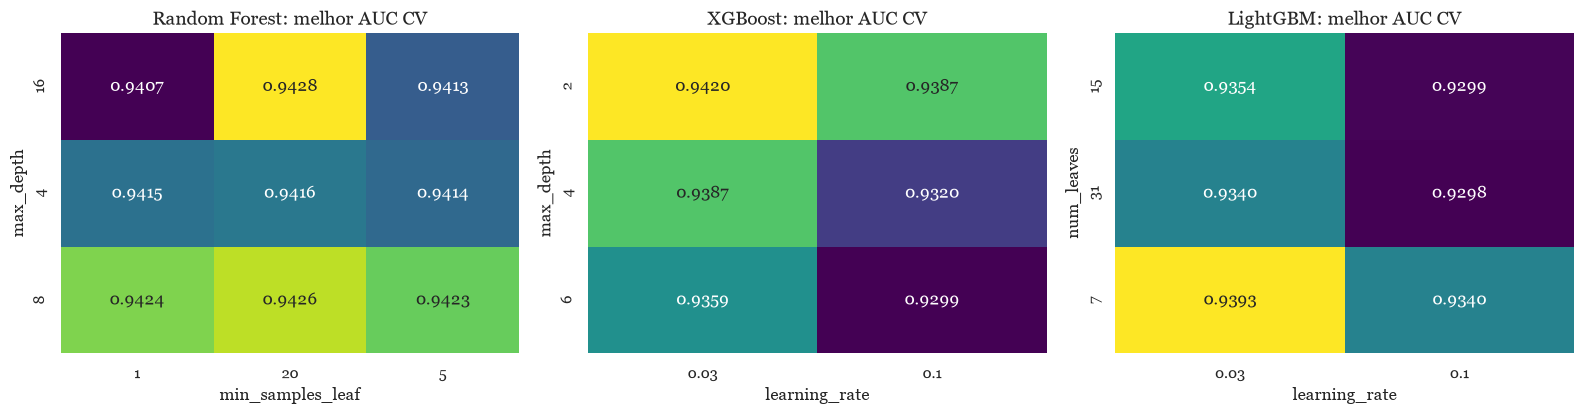

In [25]:
# Mapas de score do cv_results_ para os dois hiperparâmetros de complexidade mais relevantes de cada modelo.
eixos_mapa = {
    "Random Forest": ("modelo__max_depth", "modelo__min_samples_leaf"),
    "XGBoost": ("modelo__max_depth", "modelo__learning_rate"),
    "LightGBM": ("modelo__num_leaves", "modelo__learning_rate"),
}
fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))
for ax, modelo in zip(axes, MODELOS):
    cvr = pd.DataFrame(resultados_grid[modelo]["busca"].cv_results_)
    linha, coluna = eixos_mapa[modelo]
    cvr[linha] = cvr["param_" + linha].astype(str)
    cvr[coluna] = cvr["param_" + coluna].astype(str)
    mapa = cvr.pivot_table(index=linha, columns=coluna, values="mean_test_score", aggfunc="max")
    sns.heatmap(mapa, annot=True, fmt=".4f", cmap="viridis", ax=ax, cbar=False)
    ax.set_title(f"{modelo}: melhor AUC CV")
    ax.set_ylabel(linha.replace("modelo__", ""))
    ax.set_xlabel(coluna.replace("modelo__", ""))
plt.tight_layout()
plt.show()

#### 5.2 Optuna

In [26]:
# Optuna: espaços de busca contínuos/amplos e a mesma função objetivo (AUC média nos mesmos folds).
def espaco(trial, modelo):
    if modelo == "Random Forest":
        return {
            "n_estimators": trial.suggest_int("n_estimators", 100, 600, step=50),
            "max_depth": trial.suggest_int("max_depth", 3, 20),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 50, log=True),
            "max_features": trial.suggest_float("max_features", 0.2, 1.0),
        }
    if modelo == "XGBoost":
        return {
            "n_estimators": trial.suggest_int("n_estimators", 100, 800, step=50),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "max_depth": trial.suggest_int("max_depth", 2, 8),
            "min_child_weight": trial.suggest_float("min_child_weight", 1, 20, log=True),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
        }
    return {
        "n_estimators": trial.suggest_int("n_estimators", 100, 800, step=50),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 7, 63),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
    }


def objetivo(trial, modelo):
    pipe = f1.make_pipeline(FABRICAS[modelo](**espaco(trial, modelo)))
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring=METRICA_PRINCIPAL)
    trial.set_user_attr("dp", scores.std())
    return scores.mean()


resultados_optuna = {}
for modelo in MODELOS:
    estudo = optuna.create_study(direction="maximize", study_name=modelo,
                                 sampler=optuna.samplers.TPESampler(seed=SEED))
    t0 = time.perf_counter()
    estudo.optimize(lambda t: objetivo(t, modelo), n_trials=N_TRIALS)
    duracao = time.perf_counter() - t0
    resultados_optuna[modelo] = {
        "estudo": estudo,
        "params": estudo.best_params,
        "score": estudo.best_value,
        "dp": estudo.best_trial.user_attrs["dp"],
        "tempo": duracao,
        "avaliacoes": len(estudo.trials),
    }
    print(f"{modelo:14s} AUC CV = {estudo.best_value:.4f} ± {resultados_optuna[modelo]['dp']:.4f} | "
          f"{duracao:6.1f} s | melhor trial #{estudo.best_trial.number}")
    print(f"{'':14s} θ* = { {k: round(v, 4) if isinstance(v, float) else v for k, v in estudo.best_params.items()} }")

Random Forest  AUC CV = 0.9428 ± 0.0076 |   82.7 s | melhor trial #18
               θ* = {'n_estimators': 150, 'max_depth': 11, 'min_samples_leaf': 50, 'max_features': 0.2099}


XGBoost        AUC CV = 0.9440 ± 0.0085 |   27.8 s | melhor trial #8
               θ* = {'n_estimators': 150, 'learning_rate': 0.0195, 'max_depth': 2, 'min_child_weight': 2.6501, 'subsample': 0.7555, 'colsample_bytree': 0.6357, 'reg_lambda': 2.0651}


LightGBM       AUC CV = 0.9429 ± 0.0082 |   32.3 s | melhor trial #18
               θ* = {'n_estimators': 250, 'learning_rate': 0.0109, 'num_leaves': 8, 'min_child_samples': 5, 'subsample': 0.7794, 'colsample_bytree': 0.5506, 'reg_lambda': 8.0132}


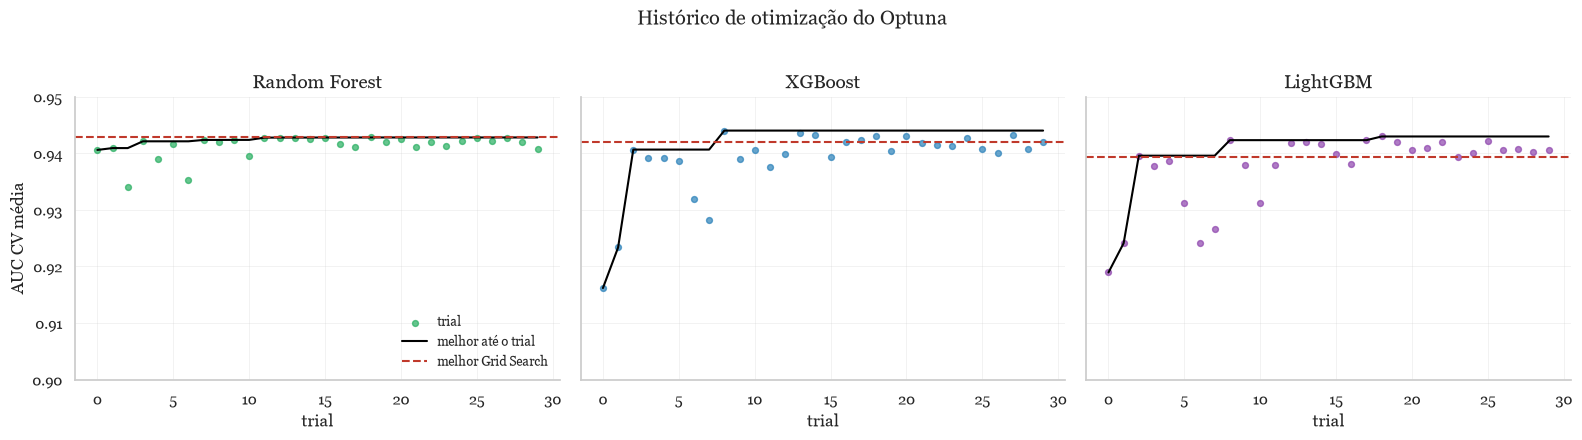

In [27]:
# Histórico de otimização do Optuna (com o melhor Grid Search como referência).
fig, axes = plt.subplots(1, 3, figsize=(16, 4.3), sharey=True)
for ax, modelo, cor in zip(axes, MODELOS, cores):
    valores = [t.value for t in resultados_optuna[modelo]["estudo"].trials]
    ax.scatter(range(len(valores)), valores, color=cor, s=18, alpha=0.7, label="trial")
    ax.plot(np.maximum.accumulate(valores), color="black", label="melhor até o trial")
    ax.axhline(resultados_grid[modelo]["score"], ls="--", color="#c0392b", label="melhor Grid Search")
    ax.set_title(f"{modelo}")
    ax.set_xlabel("trial")
axes[0].set_ylabel("AUC CV média")
axes[0].set_ylim(0.90, 0.95)
axes[0].legend(loc="lower right", fontsize=9)
plt.suptitle("Histórico de otimização do Optuna", y=1.02)
plt.tight_layout()
plt.show()

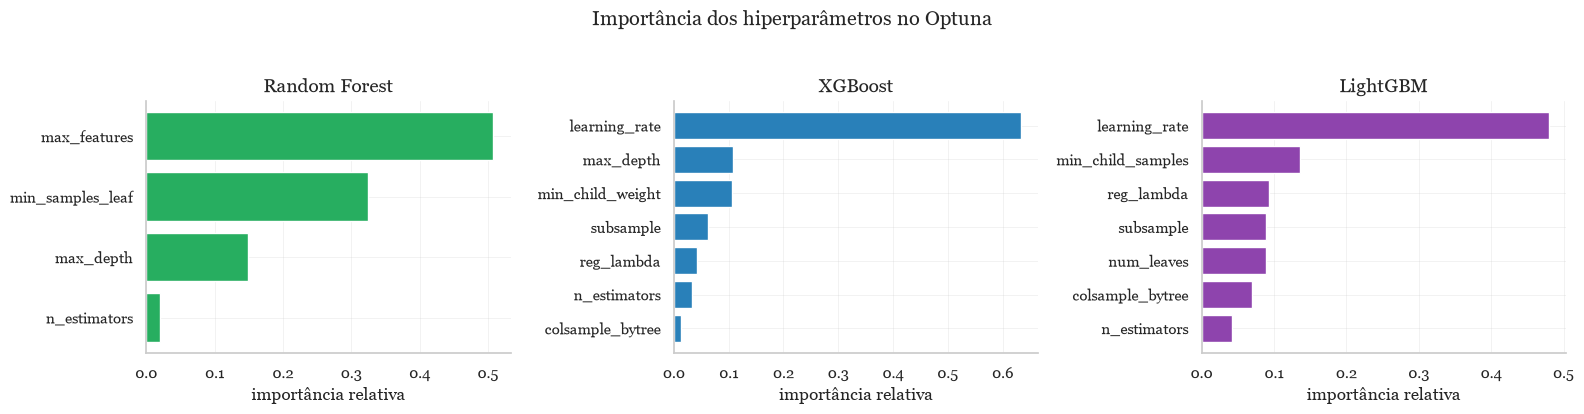

In [28]:
# Importância dos hiperparâmetros (fANOVA do Optuna).
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, modelo, cor in zip(axes, MODELOS, cores):
    imp = optuna.importance.get_param_importances(
        resultados_optuna[modelo]["estudo"],
        evaluator=optuna.importance.FanovaImportanceEvaluator(seed=SEED),
    )
    imp = pd.Series(imp).sort_values()
    ax.barh(imp.index, imp.values, color=cor)
    ax.set_title(f"{modelo}")
    ax.set_xlabel("importância relativa")
plt.suptitle("Importância dos hiperparâmetros no Optuna", y=1.03)
plt.tight_layout()
plt.show()

#### 5.3 Comparação entre Grid Search e Optuna

,modelo,estratégia,avaliações,melhor AUC CV,dp entre folds,tempo total (s),tempo por avaliação (s)
0,Random Forest,Grid Search,24,0.9428,0.0065,95.4192,3.9758
1,Random Forest,Optuna,30,0.9428,0.0076,82.6700,2.7557
2,XGBoost,Grid Search,24,0.9420,0.0093,34.2373,1.4266
3,XGBoost,Optuna,30,0.9440,0.0085,27.7652,0.9255
4,LightGBM,Grid Search,24,0.9393,0.0090,25.2613,1.0526
5,LightGBM,Optuna,30,0.9429,0.0082,32.3114,1.0770


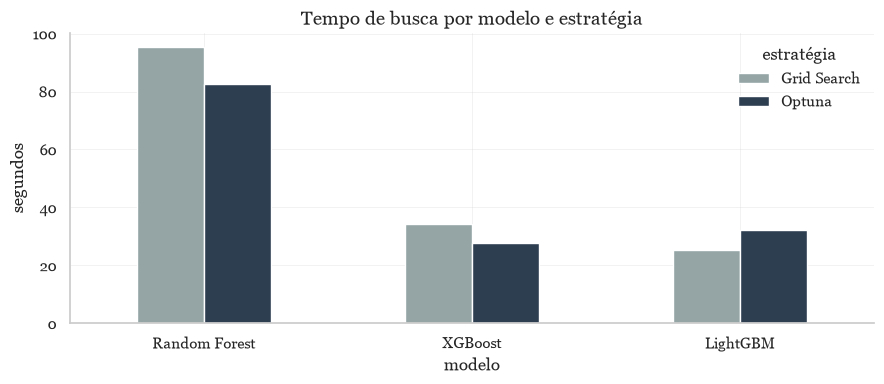

In [29]:
# Comparação entre estratégias: qualidade, estabilidade e custo.
linhas = []
for modelo in MODELOS:
    for estrategia, res in [("Grid Search", resultados_grid[modelo]), ("Optuna", resultados_optuna[modelo])]:
        linhas.append({
            "modelo": modelo, "estratégia": estrategia, "avaliações": res["avaliacoes"],
            "melhor AUC CV": res["score"], "dp entre folds": res["dp"],
            "tempo total (s)": res["tempo"], "tempo por avaliação (s)": res["tempo"] / res["avaliacoes"],
        })
comparacao_busca = pd.DataFrame(linhas)
display(comparacao_busca.round(4))

fig, ax = plt.subplots(figsize=(9, 4))
tempos = comparacao_busca.pivot(index="modelo", columns="estratégia", values="tempo total (s)").loc[MODELOS]
tempos.plot.bar(ax=ax, color=["#95a5a6", "#2c3e50"], rot=0)
ax.set_ylabel("segundos")
ax.set_title("Tempo de busca por modelo e estratégia")
plt.tight_layout()
plt.show()

**Comparação entre Grid Search e Optuna:**

- **Qualidade da solução:** as duas estratégias melhoraram todos os modelos em relação ao baseline (de 0,925–0,937 para 0,939–0,944). O Optuna encontrou a melhor solução para o XGBoost (**0,9440** × 0,9420) e para o LightGBM (0,9429 × 0,9393) e empatou no Random Forest (0,9428). **Essas diferenças, porém, são menores que o desvio-padrão entre folds (~0,007–0,009)**: em termos estatísticos, as seis soluções otimizadas são praticamente equivalentes.
- **Comportamento da busca:** as duas estratégias convergiram para a **mesma direção**, a de modelos **mais simples e mais regularizados** que os padrões: árvores rasas no XGBoost (`max_depth=2`), poucas folhas no LightGBM (7–8), folhas grandes no RF (`min_samples_leaf` 20–50) e taxas de aprendizado baixas (0,01–0,03). Isso confirma o diagnóstico de sobreajuste do Exercício 4. Nos gráficos de histórico, o melhor trial do Optuna apareceu cedo no XGBoost (trial 8) e mais tarde no RF e no LightGBM (trial 18), o que mostra que o TPE continuou encontrando melhorias depois da fase inicial de exploração. A análise de importância dos hiperparâmetros (fANOVA) mostra quais parâmetros realmente importam em cada modelo, o que ajuda a desenhar grades futuras mais enxutas.
- **Custo computacional:** os custos totais foram semelhantes (~30 s para XGBoost e LightGBM, ~80 s para o RF), mas o Optuna avaliou 30 configurações contra 24 e com um **tempo por avaliação menor** nos três modelos, em parte porque o TPE concentrou as buscas em modelos menores, que também eram os melhores.
- **Estabilidade e complexidade:** o Grid Search é totalmente determinístico e fácil de interpretar em mapas de calor, mas cresce exponencialmente com o número de hiperparâmetros (explorar os 7 do Optuna em grade seria inviável). O Optuna explora espaços contínuos e maiores com o mesmo orçamento, mas depende da semente e do número de trials.

**Conclusão:** neste problema, o **Optuna foi a estratégia mais eficiente**, com soluções iguais ou ligeiramente melhores, um espaço de busca muito maior e custo equivalente. O principal ganho, porém, veio de **reduzir a complexidade dos modelos**, algo que as duas estratégias identificaram.

<br>

---

<br>

### **Exercício 6 — Escolha do melhor modelo e análise de overfitting/underfitting — 1,5 ponto**

Com base apenas nos resultados de treinamento e validação cruzada, escolha a configuração que será promovida a modelo final. A escolha deve considerar desempenho, variabilidade entre folds, diferença entre treino e validação, custo e complexidade.

1. **Seleção do modelo — 0,50 ponto.** Construa uma tabela final com, no mínimo, as nove configurações principais: baseline, melhor Grid Search e melhor Optuna para cada um dos três algoritmos. Defina qual configuração será levada ao teste final e justifique a decisão.
2. **Overfitting e underfitting — 0,50 ponto.** Compare desempenho de treino e validação e produza uma **curva de aprendizado** para a configuração escolhida. Discuta se há evidências de overfitting, underfitting ou comportamento compatível com boa generalização.
3. **Interpretação do comportamento do modelo — 0,50 ponto.** Produza um gráfico de importância das variáveis para o modelo escolhido e pelo menos um gráfico de desempenho adequado ao tipo de problema:
   - **classificação:** matriz de confusão e, quando pertinente, curva ROC ou Precision–Recall;
   - **regressão:** valores observados versus previstos e/ou análise de resíduos.

Para uma métrica em que valores maiores representam melhor desempenho, um indício simples de sobreajuste pode ser observado pelo gap

$$
\Delta_{\uparrow}=S_{\mathrm{treino}}-S_{\mathrm{CV}}.
$$

Para uma função de erro em que valores menores são melhores, considere

$$
\Delta_{\downarrow}=L_{\mathrm{CV}}-L_{\mathrm{treino}}.
$$

Um gap elevado pode indicar sobreajuste, mas a conclusão deve considerar também a curva de aprendizado, a variabilidade dos folds e a escala da métrica.

**Resposta do aluno — Exercício 6**

A seleção usa **apenas** resultados de treino e validação cruzada. As nove configurações são reavaliadas nos mesmos 5 folds para obter, de forma padronizada, a AUC de treino, a média e o desvio da validação, o gap, as métricas auxiliares e o tempo.

#### 6.1 Seleção do modelo

In [30]:
# Resposta do aluno - exercício 6
# Tabela final com as nove configurações, reavaliadas nos mesmos folds com score de treino.
configuracoes = {}
for modelo in MODELOS:
    configuracoes[(modelo, "baseline")] = {}
    configuracoes[(modelo, "Grid Search")] = resultados_grid[modelo]["params"]
    configuracoes[(modelo, "Optuna")] = resultados_optuna[modelo]["params"]

linhas = []
for (modelo, conf), params in configuracoes.items():
    linha, _ = avaliar_cv(modelo, conf, params)
    linhas.append(linha)
tabela_final = pd.DataFrame(linhas)
display(tabela_final[["modelo", "configuração"] + colunas_principais]
        .sort_values("AUC CV média", ascending=False).round(4))

,modelo,configuração,AUC treino,AUC CV média,AUC CV dp,gap (treino - CV),average_precision CV,f1 CV,tempo de treino por fold (s)
5,XGBoost,Optuna,0.9499,0.9440,0.0085,0.0059,0.7383,0.6798,0.1051
8,LightGBM,Optuna,0.9538,0.9429,0.0082,0.0109,0.7280,0.6827,0.1036
1,Random Forest,Grid Search,0.9567,0.9428,0.0065,0.0139,0.7307,0.6674,0.7754
2,Random Forest,Optuna,0.9522,0.9428,0.0076,0.0094,0.7362,0.6798,0.2673
4,XGBoost,Grid Search,0.9541,0.9420,0.0093,0.0121,0.7212,0.6889,0.1031
7,LightGBM,Grid Search,0.9633,0.9393,0.0090,0.0240,0.7138,0.6825,0.0756
0,Random Forest,baseline,1.0000,0.9366,0.0111,0.0634,0.7049,0.6638,0.1896
6,LightGBM,baseline,0.9999,0.9317,0.0109,0.0682,0.6871,0.6481,0.1002
3,XGBoost,baseline,1.0000,0.9252,0.0130,0.0748,0.6821,0.6618,0.1098


In [31]:
# Regra de seleção (definida antes de olhar o teste): regra de 1 erro-padrão.
# 1) melhor média de AUC na validação cruzada;
# 2) candidatos: configurações a até 1 erro-padrão (dp / sqrt(K)) da melhor;
# 3) entre os candidatos, escolher a de menor gap treino-CV (menos sobreajuste).
melhor = tabela_final.loc[tabela_final["AUC CV média"].idxmax()]
erro_padrao = melhor["AUC CV dp"] / np.sqrt(N_FOLDS)
candidatos = tabela_final[tabela_final["AUC CV média"] >= melhor["AUC CV média"] - erro_padrao]
escolhida = candidatos.loc[candidatos["gap (treino - CV)"].idxmin()]

MODELO_FINAL = escolhida["modelo"]
CONFIG_FINAL = escolhida["configuração"]
PARAMS_FINAL = configuracoes[(MODELO_FINAL, CONFIG_FINAL)]
print(f"Melhor média: {melhor['modelo']} / {melhor['configuração']} = {melhor['AUC CV média']:.4f} "
      f"(erro-padrão {erro_padrao:.4f})")
print("Candidatos dentro de 1 erro-padrão:")
display(candidatos[["modelo", "configuração", "AUC CV média", "AUC CV dp", "gap (treino - CV)",
                    "tempo de treino por fold (s)"]].round(4))
print(f"Configuração escolhida: {MODELO_FINAL} / {CONFIG_FINAL}")
print(f"θ final: {PARAMS_FINAL}")

pipe_escolhido = f1.make_pipeline(FABRICAS[MODELO_FINAL](**PARAMS_FINAL))

Melhor média: XGBoost / Optuna = 0.9440 (erro-padrão 0.0038)
Candidatos dentro de 1 erro-padrão:


,modelo,configuração,AUC CV média,AUC CV dp,gap (treino - CV),tempo de treino por fold (s)
1,Random Forest,Grid Search,0.9428,0.0065,0.0139,0.7754
2,Random Forest,Optuna,0.9428,0.0076,0.0094,0.2673
4,XGBoost,Grid Search,0.9420,0.0093,0.0121,0.1031
5,XGBoost,Optuna,0.9440,0.0085,0.0059,0.1051
8,LightGBM,Optuna,0.9429,0.0082,0.0109,0.1036


Configuração escolhida: XGBoost / Optuna
θ final: {'n_estimators': 150, 'learning_rate': 0.01947558230629543, 'max_depth': 2, 'min_child_weight': 2.6501137707458966, 'subsample': 0.7554709158757928, 'colsample_bytree': 0.6356745158869479, 'reg_lambda': 2.0651425578959257}


**Regra de seleção e justificativa.** Como as diferenças entre as melhores configurações são pequenas, escolher simplesmente o maior número seria escolher ruído. Aplicamos a **regra de 1 erro-padrão**: são candidatas as configurações cuja média está a até 1 erro-padrão (dp/√5 ≈ 0,004) da melhor, e entre elas escolhemos a de **menor gap treino–validação**.

Cinco configurações ficaram estatisticamente empatadas (0,942–0,944). A escolhida foi o **XGBoost ajustado pelo Optuna**, que reúne ao mesmo tempo:
- a **maior média de validação** (0,9440 ± 0,0085);
- o **menor gap** entre treino e validação de todas as nove configurações (0,006), ou seja, a melhor generalização;
- o **menor tempo de treino** entre as candidatas (~0,09 s por fold);
- baixa complexidade: apenas 150 árvores de profundidade 2, com taxa de aprendizado 0,019, amostragem de linhas e colunas e regularização L2.

Os baselines ficaram claramente abaixo (0,925–0,937) e com os maiores gaps (0,06–0,07).

#### 6.2 Overfitting e underfitting

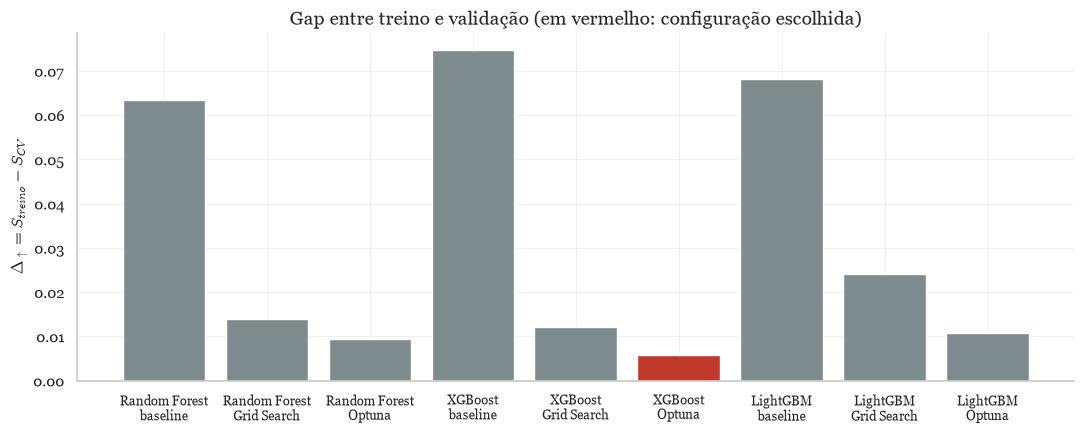

In [32]:
# Gap treino-CV das nove configurações.
fig, ax = plt.subplots(figsize=(11, 4.5))
rotulos = tabela_final["modelo"] + "\n" + tabela_final["configuração"]
ax.bar(rotulos, tabela_final["gap (treino - CV)"],
       color=["#c0392b" if (m == MODELO_FINAL and c == CONFIG_FINAL) else "#7f8c8d"
              for m, c in zip(tabela_final["modelo"], tabela_final["configuração"])])
ax.set_ylabel(r"$\Delta_{\uparrow} = S_{treino} - S_{CV}$")
ax.set_title("Gap entre treino e validação (em vermelho: configuração escolhida)")
plt.xticks(fontsize=9)
plt.tight_layout()
plt.show()

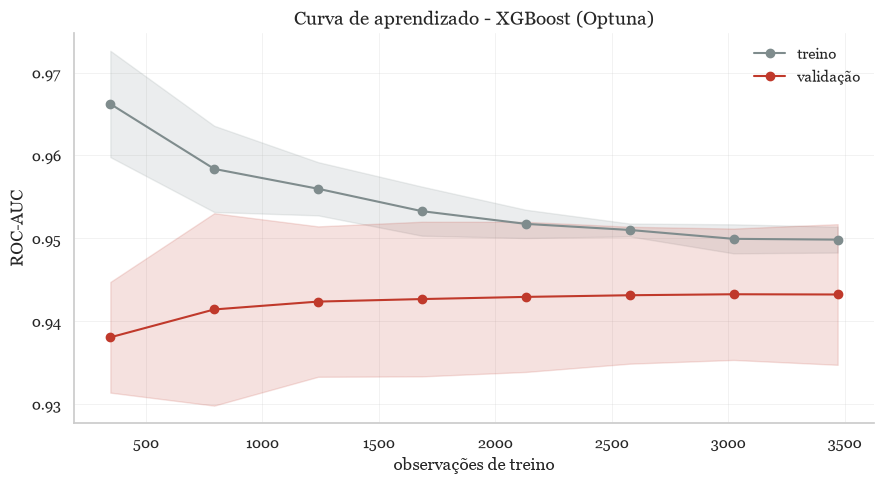

,n treino,AUC treino,AUC validação,dp validação
0,347,0.9662,0.9380,0.0067
1,793,0.9584,0.9414,0.0116
2,1239,0.9560,0.9424,0.0091
3,1685,0.9533,0.9427,0.0093
4,2131,0.9517,0.9429,0.0091
5,2577,0.9510,0.9431,0.0083
6,3023,0.9499,0.9432,0.0079
7,3470,0.9498,0.9432,0.0085


In [33]:
# Curva de aprendizado da configuração escolhida (mesmos folds, apenas D_treino).
tamanhos, sc_treino, sc_val = learning_curve(
    pipe_escolhido, X_train, y_train, cv=cv, scoring=METRICA_PRINCIPAL,
    train_sizes=np.linspace(0.1, 1.0, 8), shuffle=True, random_state=SEED,
)
fig, ax = plt.subplots(figsize=(9, 5))
for sc, rotulo, cor in [(sc_treino, "treino", "#7f8c8d"), (sc_val, "validação", "#c0392b")]:
    ax.plot(tamanhos, sc.mean(axis=1), marker="o", color=cor, label=rotulo)
    ax.fill_between(tamanhos, sc.mean(axis=1) - sc.std(axis=1), sc.mean(axis=1) + sc.std(axis=1),
                    color=cor, alpha=0.15)
ax.set_xlabel("observações de treino")
ax.set_ylabel("ROC-AUC")
ax.set_title(f"Curva de aprendizado - {MODELO_FINAL} ({CONFIG_FINAL})")
ax.legend()
plt.tight_layout()
plt.show()
display(pd.DataFrame({"n treino": tamanhos, "AUC treino": sc_treino.mean(axis=1),
                      "AUC validação": sc_val.mean(axis=1), "dp validação": sc_val.std(axis=1)}).round(4))

**Análise de overfitting e underfitting:**

- **Gap treino–CV:** caiu de 0,06–0,07 nos baselines (AUC de treino ≈ 1,0, memorização) para **0,006** na configuração escolhida (0,950 no treino × 0,944 na validação). O tuning eliminou o sobreajuste sem perder desempenho: a validação, na verdade, subiu.
- **Curva de aprendizado:** a AUC de treino **desce** suavemente (0,966 → 0,950) e a de validação **sobe** (0,938 → 0,943) à medida que o treino cresce, e as duas curvas convergem com gap pequeno. Esse é o padrão de **boa generalização**. A curva de validação praticamente **estabiliza a partir de ~2.000 observações**, então mais dados da mesma era trariam ganhos marginais.
- **Underfitting:** a curva de treino não está baixa (0,95) e o modelo supera com folga a referência ingênua (0,923). O teto de ~0,94 vem do **ruído irredutível** do esporte: quebras, acidentes, safety cars e chuva não são previsíveis com informação pré-largada.
- **Variabilidade entre folds:** o desvio-padrão (0,0085) é baixo em relação à média, então o desempenho é estável entre diferentes subconjuntos de corridas.

**Conclusão:** o comportamento é compatível com **boa generalização**, sem sinais relevantes de overfitting ou underfitting.

#### 6.3 Interpretação do comportamento do modelo

AUC out-of-fold: 0.9425
Limiar que maximiza o F1 out-of-fold: 0.388 (F1 = 0.707) | F1 com limiar 0,5: 0.679


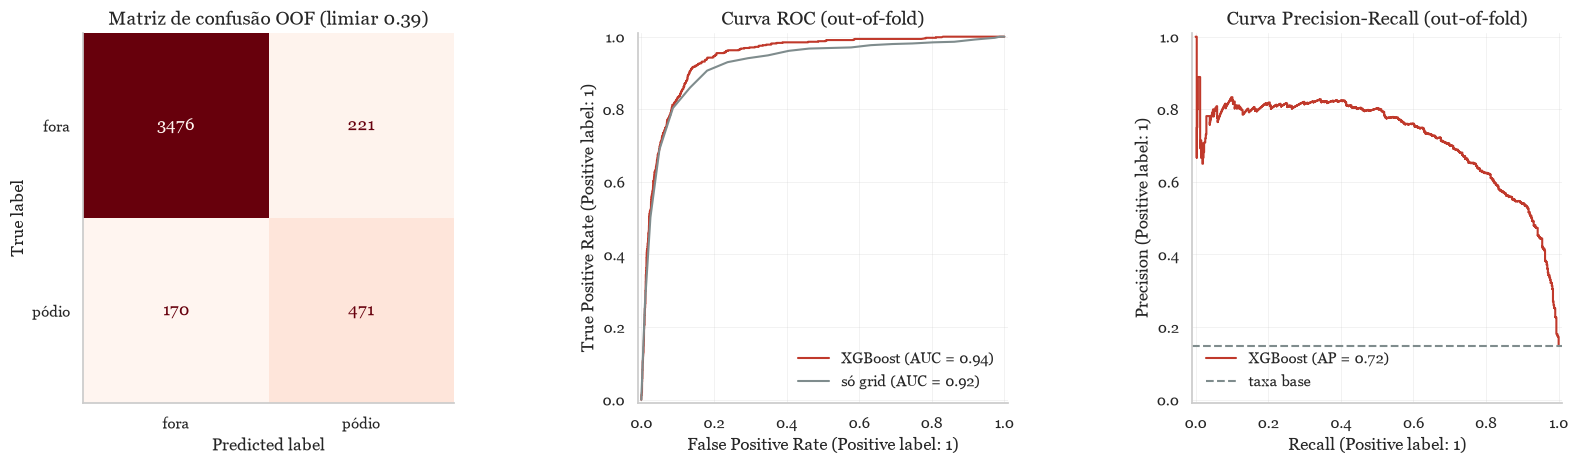

In [34]:
# Previsões out-of-fold em D_treino: cada observação é prevista por um modelo que não a viu.
proba_oof = cross_val_predict(pipe_escolhido, X_train, y_train, cv=cv, method="predict_proba")[:, 1]
print(f"AUC out-of-fold: {roc_auc_score(y_train, proba_oof):.4f}")

# Limiar de decisão escolhido nas previsões out-of-fold (maximiza F1), sem usar o teste.
precisoes, revocacoes, limiares = precision_recall_curve(y_train, proba_oof)
f1s = 2 * precisoes[:-1] * revocacoes[:-1] / (precisoes[:-1] + revocacoes[:-1] + 1e-12)
LIMIAR = float(limiares[np.argmax(f1s)])
print(f"Limiar que maximiza o F1 out-of-fold: {LIMIAR:.3f} (F1 = {f1s.max():.3f}) | F1 com limiar 0,5: "
      f"{f1_score(y_train, proba_oof >= 0.5):.3f}")

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
ConfusionMatrixDisplay.from_predictions(y_train, (proba_oof >= LIMIAR).astype(int), ax=axes[0],
                                        display_labels=["fora", "pódio"], cmap="Reds", colorbar=False)
axes[0].set_title(f"Matriz de confusão OOF (limiar {LIMIAR:.2f})")
axes[0].grid(False)
RocCurveDisplay.from_predictions(y_train, proba_oof, ax=axes[1], name=MODELO_FINAL, curve_kwargs={"color": "#c0392b"})
RocCurveDisplay.from_predictions(y_train, -X_train["grid"], ax=axes[1], name="só grid", curve_kwargs={"color": "#7f8c8d"})
axes[1].set_title("Curva ROC (out-of-fold)")
PrecisionRecallDisplay.from_predictions(y_train, proba_oof, ax=axes[2], name=MODELO_FINAL, curve_kwargs={"color": "#c0392b"})
axes[2].axhline(y_train.mean(), ls="--", color="#7f8c8d", label="taxa base")
axes[2].set_title("Curva Precision-Recall (out-of-fold)")
axes[2].legend(loc="lower left")
plt.tight_layout()
plt.show()

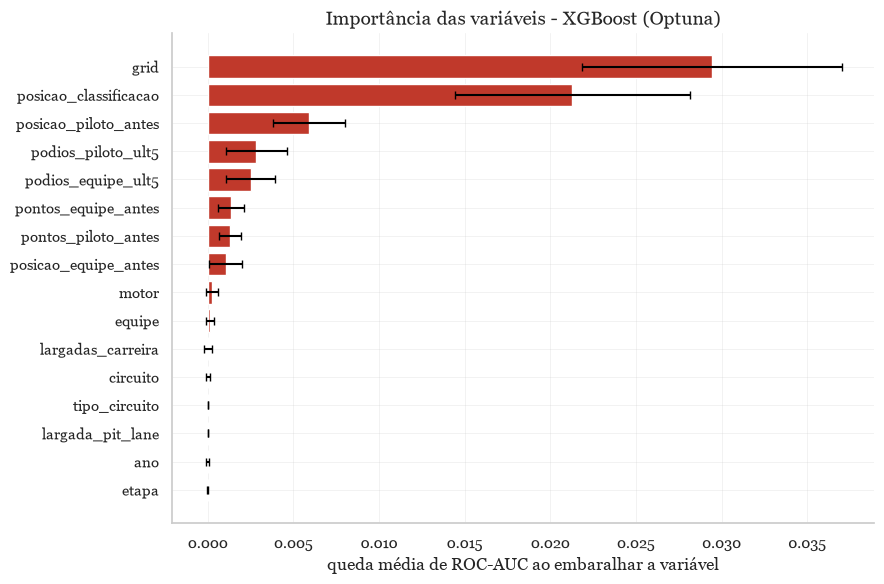

,grid,posicao_classificacao,posicao_piloto_antes,podios_piloto_ult5,podios_equipe_ult5,pontos_equipe_antes,pontos_piloto_antes,posicao_equipe_antes,motor,equipe,largadas_carreira,circuito,tipo_circuito,largada_pit_lane,ano,etapa
mean,0.0294,0.0213,0.0059,0.0028,0.0025,0.0014,0.0013,0.001,0.0003,0.0001,0.0000,0.0000,0.0,0.0,-0.0000,-0.0
std,0.0076,0.0069,0.0021,0.0018,0.0014,0.0008,0.0006,0.001,0.0003,0.0002,0.0002,0.0001,0.0,0.0,0.0001,0.0


In [35]:
# Importância por permutação, calculada nos folds de validação (variáveis originais, antes do one-hot).
importancias = []
for idx_tr, idx_val in cv.split(X_train, y_train):
    modelo_fold = clone(pipe_escolhido).fit(X_train.iloc[idx_tr], y_train.iloc[idx_tr])
    r = permutation_importance(modelo_fold, X_train.iloc[idx_val], y_train.iloc[idx_val],
                               scoring=METRICA_PRINCIPAL, n_repeats=5, random_state=SEED)
    importancias.append(r.importances_mean)
importancias = pd.DataFrame(importancias, columns=X_train.columns)
resumo_imp = importancias.agg(["mean", "std"]).T.sort_values("mean")

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(resumo_imp.index, resumo_imp["mean"], xerr=resumo_imp["std"], color="#c0392b", capsize=3)
ax.set_xlabel("queda média de ROC-AUC ao embaralhar a variável")
ax.set_title(f"Importância das variáveis - {MODELO_FINAL} ({CONFIG_FINAL})")
plt.tight_layout()
plt.show()
display(resumo_imp.sort_values("mean", ascending=False).round(4).T)

**Interpretação do comportamento do modelo:**

- **Limiar de decisão:** as previsões *out-of-fold* (cada piloto previsto por um modelo que não o viu) permitiram escolher o limiar $\tau \approx 0{,}39$, que maximiza o F1 (0,707 contra 0,679 com o limiar padrão de 0,5). Ele é menor que 0,5 porque a classe positiva é rara. O limiar foi definido **sem usar o teste**.
- **Matriz de confusão:** com esse limiar, o modelo identifica cerca de 3 em cada 4 pódios reais (recall ≈ 0,73), e cerca de 2 em cada 3 pilotos apontados como pódio de fato sobem (precision ≈ 0,68). Os erros concentram-se em pilotos de ponta que abandonam ou perdem posições (falsos positivos) e em pódios "surpresa" vindos do meio do grid (falsos negativos).
- **Curvas ROC e Precision–Recall:** a AUC out-of-fold (0,943) supera a da referência "só grid" (0,923), cuja curva aparece no mesmo gráfico, e a Average Precision (~0,72) é quase 5 vezes a taxa base (0,15).
- **Importância das variáveis (permutação nos folds de validação):** `grid` e `posicao_classificacao` são as mais importantes. Embaralhar qualquer uma delas derruba a AUC de forma relevante, mesmo com a outra presente. Em seguida vêm a **posição do piloto no campeonato** e a **forma recente** (pódios do piloto e da equipe nas últimas 5 corridas), que funcionam como proxy da qualidade do conjunto piloto + carro. Variáveis de contexto (`ano`, `etapa`, `circuito`, `tipo_circuito`) têm importância praticamente nula: o modelo não "decora" pistas nem temporadas. Como grid e classificação (ρ = 0,96), assim como pontos e posição no campeonato, são muito correlacionados, a importância por permutação de cada um **subestima** o peso conjunto do grupo.

O modelo aprendeu, portanto, uma regra coerente com o esporte: **largar na frente é o que mais importa, e o desempenho recente do piloto e da equipe ajusta essa chance.**

<br>

---

<br>

### **Exercício 7 — Teste final, consistência do modelo, entrega em produção e apresentação — 1,5 ponto**

Somente agora utilize $\mathcal{D}_{\mathrm{teste}}$. Refaça o treinamento da configuração selecionada usando todo $\mathcal{D}_{\mathrm{treino}}$ e execute a avaliação final uma única vez no conjunto de teste.

1. **Avaliação final — 0,50 ponto.** Calcule a métrica principal e as métricas auxiliares em $\mathcal{D}_{\mathrm{teste}}$. Compare o resultado de teste com a validação cruzada. Discuta se o desempenho final é compatível com o que era esperado durante o desenvolvimento.
2. **Teste de consistência — 0,40 ponto.** Selecione pelo menos cinco observações que não participaram do treinamento. Para cada uma, apresente as principais entradas, o valor real $y$, a previsão $\hat{y}$ e:
   - em classificação, a probabilidade prevista quando o estimador oferecer `predict_proba`;
   - em regressão, o erro individual $e_i=y_i-\hat{y}_i$.

   Interprete os casos e verifique se o comportamento do modelo é coerente com o padrão aprendido. Inclua pelo menos um caso em que o modelo acerta bem e um caso mais difícil, quando isso existir nos dados.
3. **GitHub e Streamlit — 0,60 ponto.** Disponibilize o projeto em um repositório GitHub e construa uma aplicação Streamlit que utilize **a mesma preparação de dados e o mesmo modelo final**. A interface deve receber as variáveis necessárias, gerar a previsão e apresentar o resultado de forma legível. O repositório deve conter, no mínimo:
   - `README.md` com descrição do problema, instruções de instalação e execução, links e resumo dos resultados;
   - notebook do CheckPoint05;
   - código da aplicação Streamlit;
   - arquivo de dependências (`requirements.txt` ou equivalente);
   - artefato do pipeline/modelo final ou código reproduzível para gerá-lo;
   - instruções para obtenção da base, caso ela não possa ser versionada no repositório.

Registre abaixo os links finais:

- **GitHub:** inserir URL do repositório.
- **Streamlit:** inserir URL da aplicação.

4. **Apresentação da solução — requisito obrigatório.** O grupo deverá realizar uma apresentação oral de **no máximo 10 minutos**. A exposição deve ser objetiva e demonstrar domínio sobre o desenvolvimento realizado. Organize a apresentação para contemplar, no mínimo:
   - problema escolhido, contexto, base de dados e variável-alvo;
   - principais decisões de data wrangling e escolha das variáveis;
   - comparação entre Random Forest, XGBoost e LightGBM;
   - resultados do Grid Search e do Optuna e justificativa da configuração final;
   - análise de overfitting e underfitting;
   - desempenho no conjunto de teste e principais conclusões sobre generalização;
   - demonstração breve da aplicação Streamlit e do teste de paridade entre notebook e interface.

A apresentação poderá utilizar slides ou a demonstração direta do projeto, desde que o tempo máximo seja respeitado. Todos os integrantes devem estar preparados para responder a perguntas sobre a solução desenvolvida.

<div style="border-left: 4px solid #666; padding: 10px 16px; margin: 18px 0;">
<strong>Teste adicional de paridade:</strong> escolha pelo menos uma das observações do teste de consistência, reproduza os mesmos valores de entrada na aplicação Streamlit e verifique se a previsão exibida pela interface coincide com a previsão produzida pelo pipeline no notebook. Divergências devem ser investigadas antes da entrega.
</div>

**Resposta do aluno — Exercício 7**

Somente agora $\mathcal{D}_{\mathrm{teste}}$ é utilizado. A configuração escolhida (XGBoost + Optuna, com o limiar $\tau$ definido no Exercício 6) é treinada em todo $\mathcal{D}_{\mathrm{treino}}$ e avaliada **uma única vez** no teste.

#### 7.1 Avaliação final no conjunto de teste

,validação (D_treino),teste (D_teste),diferença
roc_auc,0.9440,0.9423,-0.0017
average_precision,0.7191,0.7178,-0.0013
f1,0.7067,0.6743,-0.0324
precision,0.6806,0.6211,-0.0596
recall,0.7348,0.7375,0.0027
accuracy,0.9099,0.8949,-0.0149


Intervalo esperado pela CV (média ± 2 dp): [0.9271, 0.9609]
Referência ingênua (só grid) no teste: 0.9177


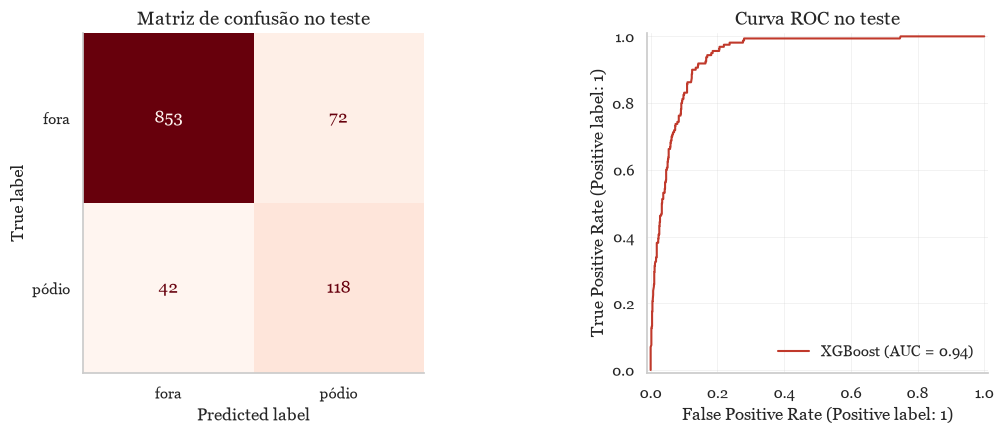

In [36]:
# Resposta do aluno - exercício 7
# Treino da configuração escolhida em todo D_treino e avaliação única em D_teste.
modelo_final = clone(pipe_escolhido).fit(X_train, y_train)
proba_teste = modelo_final.predict_proba(X_test)[:, 1]
prev_teste = (proba_teste >= LIMIAR).astype(int)

metricas_teste = {
    "roc_auc": roc_auc_score(y_test, proba_teste),
    "average_precision": average_precision_score(y_test, proba_teste),
    "f1": f1_score(y_test, prev_teste),
    "precision": precision_score(y_test, prev_teste),
    "recall": recall_score(y_test, prev_teste),
    "accuracy": accuracy_score(y_test, prev_teste),
}
# Métricas out-of-fold em D_treino com o mesmo limiar, para comparação direta.
prev_oof = (proba_oof >= LIMIAR).astype(int)
metricas_cv = {
    "roc_auc": escolhida["AUC CV média"],
    "average_precision": average_precision_score(y_train, proba_oof),
    "f1": f1_score(y_train, prev_oof),
    "precision": precision_score(y_train, prev_oof),
    "recall": recall_score(y_train, prev_oof),
    "accuracy": accuracy_score(y_train, prev_oof),
}
comparacao_teste = pd.DataFrame({"validação (D_treino)": metricas_cv, "teste (D_teste)": metricas_teste})
comparacao_teste["diferença"] = comparacao_teste["teste (D_teste)"] - comparacao_teste["validação (D_treino)"]
display(comparacao_teste.round(4))
print(f"Intervalo esperado pela CV (média ± 2 dp): "
      f"[{escolhida['AUC CV média'] - 2 * escolhida['AUC CV dp']:.4f}, "
      f"{escolhida['AUC CV média'] + 2 * escolhida['AUC CV dp']:.4f}]")
print(f"Referência ingênua (só grid) no teste: {roc_auc_score(y_test, -X_test['grid']):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ConfusionMatrixDisplay.from_predictions(y_test, prev_teste, ax=axes[0], display_labels=["fora", "pódio"],
                                        cmap="Reds", colorbar=False)
axes[0].set_title("Matriz de confusão no teste")
axes[0].grid(False)
RocCurveDisplay.from_predictions(y_test, proba_teste, ax=axes[1], name=MODELO_FINAL, curve_kwargs={"color": "#c0392b"})
axes[1].set_title("Curva ROC no teste")
plt.tight_layout()
plt.show()

In [37]:
# Artefatos do modelo final, usados pela aplicação Streamlit.
joblib.dump(modelo_final, "model/pipeline_final.joblib")
metadados = {
    "modelo": MODELO_FINAL,
    "configuracao": CONFIG_FINAL,
    "hiperparametros": {k: (float(v) if isinstance(v, (float, np.floating)) else v) for k, v in PARAMS_FINAL.items()},
    "limiar": LIMIAR,
    "taxa_base": float(y_train.mean()),  # proporção de pódios em D_treino (faixas de cor da aplicação)
    "auc_cv_media": float(escolhida["AUC CV média"]),
    "auc_cv_dp": float(escolhida["AUC CV dp"]),
    "metricas_teste": {k: float(v) for k, v in metricas_teste.items()},
    "features": f1.FEATURES,
    "categorias": {c: sorted(base[c].dropna().unique().tolist()) for c in f1.CAT_FEATURES},
    "tipo_por_circuito": base.groupby("circuito")["tipo_circuito"].agg(lambda s: s.mode()[0]).to_dict(),
    "f1db_versao": f1.F1DB_VERSION,
    "versoes": {"scikit-learn": sklearn.__version__, "xgboost": xgboost.__version__,
                "lightgbm": lightgbm.__version__, "pandas": pd.__version__},
}
Path("model/metadata.json").write_text(json.dumps(metadados, indent=2, ensure_ascii=False), encoding="utf-8")
print("Salvos: model/pipeline_final.joblib e model/metadata.json")

Salvos: model/pipeline_final.joblib e model/metadata.json


**Interpretação da avaliação final:**

- **ROC-AUC no teste = 0,942**, contra 0,944 na validação cruzada: diferença de apenas −0,002, bem dentro do intervalo esperado pela CV (média ± 2 dp = [0,927; 0,961]). A Average Precision também praticamente não mudou (0,718 × 0,719). **O desempenho final é exatamente o que o desenvolvimento previa**, sinal de que o protocolo não vazou informação do teste e de que a estimativa da validação cruzada era confiável.
- **Ganho sobre a referência:** no teste, ordenar só pelo grid dá 0,918, e o modelo dá 0,942. A informação de campeonato e forma recente agrega valor real e generalizável.
- **Métricas dependentes do limiar:** o recall se manteve (0,74), enquanto a precision caiu um pouco (0,68 → 0,62) e, com ela, o F1 (0,71 → 0,67). Essas métricas são mais sensíveis ao tamanho da amostra: o teste tem só 160 pódios, e poucos falsos positivos a mais movem a precision vários pontos. Como a métrica principal, que independe do limiar, é estável, a variação é compatível com flutuação amostral, e não com sobreajuste.
- **Artefatos:** o pipeline completo (preparação + modelo) foi salvo em `model/pipeline_final.joblib`, e os metadados (hiperparâmetros, limiar, métricas, categorias e versões) em `model/metadata.json`. A aplicação Streamlit carrega esses mesmos arquivos.

In [38]:
# Margem de erro do resultado no teste: intervalo de confiança de 95% por bootstrap
# (reamostragem das 1.085 observações de teste; nenhuma decisão de modelo é tomada aqui).
rng = np.random.default_rng(SEED)
auc_boot, ganho_boot, ap_boot = [], [], []
y_arr, grid_score = y_test.to_numpy(), -X_test["grid"].to_numpy()
for _ in range(2000):
    idx = rng.integers(0, len(y_arr), len(y_arr))
    auc_boot.append(roc_auc_score(y_arr[idx], proba_teste[idx]))
    ganho_boot.append(auc_boot[-1] - roc_auc_score(y_arr[idx], grid_score[idx]))
    ap_boot.append(average_precision_score(y_arr[idx], proba_teste[idx]))

margem = pd.DataFrame({
    "estimativa": [metricas_teste["roc_auc"], metricas_teste["roc_auc"] - roc_auc_score(y_test, -X_test["grid"]),
                   metricas_teste["average_precision"]],
    "IC 95% inferior": [np.percentile(v, 2.5) for v in (auc_boot, ganho_boot, ap_boot)],
    "IC 95% superior": [np.percentile(v, 97.5) for v in (auc_boot, ganho_boot, ap_boot)],
}, index=["ROC-AUC no teste", "ganho sobre a referência 'só grid'", "Average Precision no teste"])
display(margem.round(4))
print(f"Proporção das reamostragens em que o modelo supera a referência: {np.mean(np.array(ganho_boot) > 0):.2%}")

# Leitura por faixas (as mesmas cores da aplicação): taxa real de pódio em cada faixa.
TAXA_BASE = y_train.mean()
faixa = pd.cut(proba_teste, [-0.01, TAXA_BASE, LIMIAR, 1.01],
               labels=["vermelho (< taxa média)", "amarelo (taxa média a limiar)", "verde (>= limiar)"], right=False)
faixas = pd.DataFrame({"faixa": faixa, "podio": y_arr}).groupby("faixa", observed=True)["podio"].agg(
    observações="size", pódios="sum", taxa_real_de_pódio="mean")
display(faixas.round(3))

,estimativa,IC 95% inferior,IC 95% superior
ROC-AUC no teste,0.9423,0.9275,0.9570
ganho sobre a referência 'só grid',0.0246,0.0091,0.0431
Average Precision no teste,0.7178,0.6485,0.7861


Proporção das reamostragens em que o modelo supera a referência: 99.95%


,observações,pódios,taxa_real_de_pódio
faixa,,,
vermelho (< taxa média),787,13,0.017
amarelo (taxa média a limiar),108,29,0.269
verde (>= limiar),190,118,0.621


**Margem de erro e leitura prática do resultado:**

- **ROC-AUC no teste = 0,942, com intervalo de confiança de 95% entre ~0,93 e ~0,96.** O intervalo é estreito: mesmo no pior cenário plausível, o modelo continua muito bom.
- **O ganho sobre a referência "só grid" é real:** +0,025 de AUC, com IC 95% de ~+0,01 a ~+0,04, que **não inclui o zero**. O modelo supera a referência em praticamente todas as 2.000 reamostragens. As variáveis de campeonato e forma recente agregam informação de verdade, e o resultado não é sorte da amostra de teste.
- **As faixas de cor usadas na aplicação são bem calibradas no teste:** entre os pilotos na faixa **verde**, cerca de **62%** subiram ao pódio; na **amarela**, cerca de **27%** (quase o dobro da média); na **vermelha**, menos de **2%**. Quando o modelo aponta vermelho, ele praticamente nunca erra.

#### 7.2 Teste de consistência

In [39]:
# Casos de D_teste (não participaram do treino) escolhidos para cobrir acertos e erros.
teste = base.loc[X_test.index].assign(probabilidade=proba_teste, previsao=prev_teste)
selecao = {
    "Favorito que confirmou o pódio": teste[teste["podio"] == 1]["probabilidade"].idxmax(),
    "Fora do pódio, previsto com segurança": teste[(teste["podio"] == 0) & (teste["grid"] <= 10)]["probabilidade"].idxmin(),
    "Caso de fronteira (perto do limiar)": (teste["probabilidade"] - LIMIAR).abs().idxmin(),
    "Pódio vindo de trás (difícil)": teste[teste["podio"] == 1]["probabilidade"].idxmin(),
    "Favorito que não subiu ao pódio (difícil)": teste[teste["podio"] == 0]["probabilidade"].idxmax(),
    "Largada do pit lane": teste[teste["largada_pit_lane"] == 1]["probabilidade"].idxmax(),
}
casos = teste.loc[list(selecao.values())].assign(caso=list(selecao.keys()))
casos["acertou"] = np.where(casos["previsao"] == casos["podio"], "sim", "não")

colunas_exibicao = ["caso", "date", "driverId", "equipe", "circuito", "grid", "posicao_classificacao",
                    "posicao_piloto_antes", "podios_piloto_ult5", "positionText", "podio",
                    "probabilidade", "previsao", "acertou"]
display(casos[colunas_exibicao].assign(date=casos["date"].dt.date).round(3).reset_index(drop=True))

# Os casos são salvos para o teste de paridade na aplicação Streamlit.
casos[["caso", "date", "driverId", "positionText"] + f1.FEATURES + ["podio", "probabilidade"]].to_csv(
    "data/casos_consistencia.csv", index=False)

,caso,date,driverId,equipe,circuito,grid,posicao_classificacao,posicao_piloto_antes,podios_piloto_ult5,positionText,podio,probabilidade,previsao,acertou
0,Favorito que confirmou o pódio,2017-10-08,lewis-hamilton,mercedes,suzuka,1.0,1.0,1.0,4.0,1,1,0.793,1,sim
1,"Fora do pódio, previsto com segurança",2014-07-27,daniil-kvyat,racing-bulls,hungaroring,10.0,11.0,15.0,0.0,14,0,0.016,0,sim
2,Caso de fronteira (perto do limiar),2022-07-10,george-russell,mercedes,spielberg,4.0,4.0,5.0,2.0,4,0,0.388,0,sim
3,Pódio vindo de trás (difícil),2024-11-03,pierre-gasly,alpine,interlagos,13.0,15.0,16.0,0.0,3,1,0.015,0,não
4,Favorito que não subiu ao pódio (difícil),2014-07-27,nico-rosberg,mercedes,hungaroring,1.0,1.0,1.0,4.0,4,0,0.780,1,não
5,Largada do pit lane,2014-11-23,sebastian-vettel,red-bull,yas-marina,19.0,NaN,4.0,2.0,8,0,0.126,0,sim


**Interpretação dos casos (todos do conjunto de teste, nunca vistos no treino):**

1. **Favorito que confirmou o pódio — Hamilton, Suzuka 2017** (pole, líder do campeonato, 4 pódios nas últimas 5 corridas): probabilidade de **79%**, e ele venceu. É o padrão mais forte que o modelo aprendeu.
2. **Fora do pódio, previsto com segurança — Kvyat, Hungria 2014** (10º no grid, 15º no campeonato, sem pódios recentes, equipe do meio do pelotão): **1,6%**, e ele terminou em 14º. Mesmo largando no top 10, o modelo combinou equipe e forma fracas para dar chance mínima.
3. **Caso de fronteira — Russell, Áustria 2022** (4º no grid, 2 pódios recentes): **38,8%**, praticamente sobre o limiar (38,8%). Ele terminou exatamente em 4º, a uma posição do pódio. O modelo expressou bem a incerteza.
4. **Pódio vindo de trás (difícil) — Gasly, Interlagos 2024** (13º no grid, 16º no campeonato, sem pódios recentes): **1,5%**, mas ele terminou em **3º**, em uma corrida caótica com chuva e bandeira vermelha. É um **erro esperado**: nada antes da largada indicava esse resultado. Faz parte do ruído irredutível discutido no Exercício 6.
5. **Favorito que não subiu ao pódio (difícil) — Rosberg, Hungria 2014** (pole, líder do campeonato): **78%**, mas terminou em **4º**, em uma corrida com chuva e safety car. O modelo "errou", mas a probabilidade era coerente com a situação: um pole-position sobe ao pódio em 81% das vezes, então 1 em cada 5 falha. Curiosamente, os casos 2 e 5 são da **mesma corrida**, em que o modelo acertou um e errou o outro.
6. **Largada do pit lane — Vettel, Abu Dhabi 2014** (piloto de equipe forte, 4º no campeonato, largando do pit lane): **12,6%**. O modelo reduziu bastante a chance por causa da largada no fundo, mas não a zerou, por causa da força do piloto. Ele terminou em 8º.

**Conclusão:** o comportamento é coerente com o padrão aprendido. As probabilidades são altas para quem larga na frente em boa fase, baixas para quem larga atrás em equipes fracas e intermediárias quando os sinais conflitam. Os erros ocorrem em eventos de corrida imprevisíveis (chuva, safety car, acidentes), e não por falha de lógica do modelo.

#### 7.3 GitHub, Streamlit e teste de paridade

In [40]:
# Teste de paridade automatizado: a aplicação é executada (streamlit.testing), cada caso é
# selecionado na interface e a probabilidade exibida é comparada com a do notebook.
from streamlit.testing.v1 import AppTest

logging.disable(logging.WARNING)  # avisos "bare mode" são esperados ao rodar a aplicação fora do servidor

paridade = []
for _, linha in casos.iterrows():
    app = AppTest.from_file(str(Path("app.py").resolve()), default_timeout=120).run()
    app.selectbox(key="caso").select(linha["caso"]).run()
    proba_app = app.session_state["probabilidade"]
    paridade.append({"caso": linha["caso"], "notebook": linha["probabilidade"], "Streamlit": proba_app,
                     "diferença absoluta": abs(linha["probabilidade"] - proba_app)})
paridade = pd.DataFrame(paridade)
display(paridade.round(6))
assert np.allclose(paridade["notebook"], paridade["Streamlit"], atol=1e-6), "Divergência entre app e notebook!"
logging.disable(logging.NOTSET)
print("Paridade confirmada: a aplicação reproduz exatamente as previsões do notebook.")

,caso,notebook,Streamlit,diferença absoluta
0,Favorito que confirmou o pódio,0.792791,0.792791,0.0
1,"Fora do pódio, previsto com segurança",0.016315,0.016315,0.0
2,Caso de fronteira (perto do limiar),0.387865,0.387865,0.0
3,Pódio vindo de trás (difícil),0.014905,0.014905,0.0
4,Favorito que não subiu ao pódio (difícil),0.780451,0.780451,0.0
5,Largada do pit lane,0.126225,0.126225,0.0


Paridade confirmada: a aplicação reproduz exatamente as previsões do notebook.


**Aplicação e repositório.** A aplicação Streamlit (`app.py`) carrega o **mesmo artefato** salvo acima (`model/pipeline_final.joblib`), que inclui a preparação de `f1_pipeline.py`. A interface recebe as 16 variáveis pré-corrida e exibe a probabilidade de pódio em três faixas de cor: **verde** a partir do limiar escolhido na validação cruzada (o modelo prevê pódio), **amarelo** entre a taxa média de pódios (~14,8%) e o limiar, e **vermelho** abaixo da taxa média. Também mostra os dados enviados ao pipeline. Ela também permite **carregar os casos do teste de consistência**, o que facilita o teste de paridade ao vivo na apresentação.

**Teste de paridade:** a célula acima executa a própria aplicação (`streamlit.testing`), seleciona cada caso na interface e compara a probabilidade exibida com a do notebook. A **diferença foi 0 nos 6 casos**: a interface reproduz exatamente o pipeline avaliado.

O repositório contém: `README.md` (problema, instalação, execução, links e resultados), este notebook, `app.py`, `f1_pipeline.py`, `requirements.txt` (com versões fixadas), `model/` (artefato e metadados) e `data/` (base F1DB versionada, com instruções de download automático).

In [41]:
# Links finais do projeto.
URL_GITHUB = "PREENCHER_COM_URL_DO_REPOSITORIO"
URL_STREAMLIT = "PREENCHER_COM_URL_DA_APLICACAO"

print("GitHub:", URL_GITHUB)
print("Streamlit:", URL_STREAMLIT)

GitHub: PREENCHER_COM_URL_DO_REPOSITORIO
Streamlit: PREENCHER_COM_URL_DA_APLICACAO


**Síntese para a apresentação (até 10 minutos):**

| Tempo | Tópico | Mensagem-chave |
|---|---|---|
| 0:00–1:00 | Problema | "Antes da largada, qual a chance de pódio?" Classificação binária, F1DB (CC BY 4.0), era híbrida 2014–2026, unidade = piloto × corrida. |
| 1:00–2:30 | Dados e wrangling | Unificação de 24 nomes de equipe em 13 linhagens e de motores rebatizados; largadas do pit lane; campeonato **antes** da corrida; forma recente com `shift`. |
| 2:30–3:30 | Variáveis e protocolo | 20 colunas de data leakage removidas; split 80/20 estratificado; 5 folds fixos; ROC-AUC por causa do desbalanceamento (15%); referência "só grid" = 0,92. |
| 3:30–5:00 | Baselines | Os três superam a referência, mas com AUC de treino ≈ 1,0: overfitting. |
| 5:00–6:30 | Grid Search × Optuna | As duas estratégias levaram a modelos mais simples; Optuna igual ou melhor, com espaço maior e custo semelhante; diferenças menores que o desvio entre folds. |
| 6:30–7:30 | Modelo final e generalização | Regra de 1 erro-padrão → XGBoost + Optuna (maior AUC, menor gap). Curva de aprendizado convergente. Grid e classificação dominam; forma e campeonato ajustam. |
| 7:30–8:30 | Teste final | AUC 0,942 no teste (IC 95%: 0,93–0,96) × 0,944 na CV; ganho sobre o "só grid" com IC acima de zero. Faixas: verde → 62% de pódio, vermelho → menos de 2%. Casos: Hamilton × Rosberg × Gasly. |
| 8:30–10:00 | Demonstração | Streamlit: carregar um caso, mostrar a paridade com o notebook e simular um cenário manual. |

<br>

---

<br>

# **Referências**

* BREIMAN, Leo. Random Forests. *Machine Learning*, v. 45, p. 5–32, 2001.

* CHEN, Tianqi; GUESTRIN, Carlos. XGBoost: A Scalable Tree Boosting System. In: *Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*, 2016.

* KE, Guolin et al. LightGBM: A Highly Efficient Gradient Boosting Decision Tree. In: *Advances in Neural Information Processing Systems*, 2017.

* AKIBA, Takuya et al. Optuna: A Next-generation Hyperparameter Optimization Framework. In: *Proceedings of the 25th ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*, 2019.

* GÉRON, Aurélien. *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow*. 3. ed. Sebastopol: O'Reilly Media, 2023.

* KUHN, Max; JOHNSON, Kjell. *Feature Engineering and Selection: A Practical Approach for Predictive Models*. Boca Raton: CRC Press, 2020.

<br>

---

<br>

© 2026 Jones Egydio. Todos os direitos reservados.  

Conecte-se comigo no [LinkedIn](https://www.linkedin.com/in/jones-egydio-msc-3300359/).